In [163]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
import os
import sys

# Verificar qual Python está sendo usado
print(f"Python em uso: {sys.executable}")

# Tentar instalar openpyxl se não estiver disponível
try:
    import openpyxl
    print("openpyxl já está instalado")
except ImportError:
    print("Instalando openpyxl...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
    import openpyxl
    print("openpyxl instalado com sucesso")

# 1. CARREGAR OS DADOS
# Usar caminho completo para garantir que o arquivo seja encontrado
file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
print(f"Procurando arquivo em: {file_path}")
print(f"Arquivo existe: {os.path.exists(file_path)}")

df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

Python em uso: c:\dev\projeto_cimento\venv\Scripts\python.exe
openpyxl já está instalado
Procurando arquivo em: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\projeto_cimento\Proj_Cimento\teste banco de dados.xlsx
Arquivo existe: True


In [164]:
# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols].values
y = df[target_col].values

# 3. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. NORMALIZAR DADOS PARA TREINAMENTO DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [165]:
# 5. TREINAR REDE NEURAL (MLPRegressor)
model = MLPRegressor(
    hidden_layer_sizes=(128, 64),  # Duas camadas ocultas: 128 e 64 neurônios
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    alpha=0.2,  # L2 regularization (equivalente ao Dropout)
    max_iter=200,
    random_state=42,
    verbose=True
)

# Treinar o modelo
history = model.fit(X_train_scaled, y_train)

# Avaliar modelo
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"MLP - MAE: {mae:.4f}, Loss (MSE): {mse:.4f}")

Iteration 1, loss = 15.67408292
Iteration 2, loss = 14.65880329
Iteration 3, loss = 13.66202502
Iteration 4, loss = 12.70910511
Iteration 5, loss = 11.78837379
Iteration 6, loss = 10.85700337
Iteration 7, loss = 9.94039757
Iteration 8, loss = 9.04470146
Iteration 9, loss = 8.16024532
Iteration 10, loss = 7.31808618
Iteration 11, loss = 6.50075432
Iteration 12, loss = 5.75049379
Iteration 13, loss = 5.05683311
Iteration 14, loss = 4.43735347
Iteration 15, loss = 3.92148731
Iteration 16, loss = 3.46820870
Iteration 17, loss = 3.12364033
Iteration 18, loss = 2.86992312
Iteration 19, loss = 2.67069778
Iteration 20, loss = 2.52805236
Iteration 21, loss = 2.40901427
Iteration 22, loss = 2.30589449
Iteration 23, loss = 2.20022023
Iteration 24, loss = 2.09367857
Iteration 25, loss = 1.99042596
Iteration 26, loss = 1.88129306
Iteration 27, loss = 1.78292474
Iteration 28, loss = 1.68488176
Iteration 29, loss = 1.60429555
Iteration 30, loss = 1.53172512
Iteration 31, loss = 1.47410961
Iteration 3

In [166]:
# 6. GERAR PREVISÕES DA MLP PARA TODO DATASET (unidades originais)
X_scaled_full = scaler.transform(X)
y_pred_mlp_full = model.predict(X_scaled_full)

In [167]:
# 2. DEFINIR FEATURES E TARGET (fR,1)

feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols].values
y = df[target_col].values


In [168]:
# 3. DIVISÃO TREINO / TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [169]:
# 4. NORMALIZAÇÃO DOS DADOS
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [170]:
# 5. DEFINIÇÃO DA REDE NEURAL MLP

model = MLPRegressor(
    hidden_layer_sizes=(128, 64),  # Duas camadas ocultas: 128 e 64 neurônios
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    alpha=0.2,  # L2 regularization (equivalente ao Dropout)
    max_iter=200,
    random_state=42,
    verbose=True
)

In [171]:
# 7. AVALIAÇÃO COMPLETA DA MLP — fR,1 (TUDO EM UMA CÉLULA)

# Primeiro, garantir que o modelo está definido e treinado
print("1. Definindo e treinando o modelo...")

model = MLPRegressor(
    hidden_layer_sizes=(128, 64),  # Duas camadas ocultas: 128 e 64 neurônios
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    alpha=0.2,  # L2 regularization (equivalente ao Dropout)
    max_iter=200,
    random_state=42,
    verbose=True
)

# Treinar o modelo
print("2. Treinando o modelo...")
history = model.fit(X_train_scaled, y_train)
print("✅ Modelo treinado com sucesso!")

# Agora avaliar
print("3. Avaliando o modelo...")
y_pred_mlp = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_mlp)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2 = r2_score(y_test, y_pred_mlp)

print("\nMLP — fR,1")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

# Gerar previsões para todo dataset
print("4. Gerando previsões para todo dataset...")
X_scaled_full = scaler.transform(X)
y_pred_mlp_full = model.predict(X_scaled_full)
print(f"✅ Previsões geradas para {len(y_pred_mlp_full)} amostras")

1. Definindo e treinando o modelo...
2. Treinando o modelo...
Iteration 1, loss = 15.67408292
Iteration 2, loss = 14.65880329
Iteration 3, loss = 13.66202502
Iteration 4, loss = 12.70910511
Iteration 5, loss = 11.78837379
Iteration 6, loss = 10.85700337
Iteration 7, loss = 9.94039757
Iteration 8, loss = 9.04470146
Iteration 9, loss = 8.16024532
Iteration 10, loss = 7.31808618
Iteration 11, loss = 6.50075432
Iteration 12, loss = 5.75049379
Iteration 13, loss = 5.05683311
Iteration 14, loss = 4.43735347
Iteration 15, loss = 3.92148731
Iteration 16, loss = 3.46820870
Iteration 17, loss = 3.12364033
Iteration 18, loss = 2.86992312
Iteration 19, loss = 2.67069778
Iteration 20, loss = 2.52805236
Iteration 21, loss = 2.40901427
Iteration 22, loss = 2.30589449
Iteration 23, loss = 2.20022023
Iteration 24, loss = 2.09367857
Iteration 25, loss = 1.99042596
Iteration 26, loss = 1.88129306
Iteration 27, loss = 1.78292474
Iteration 28, loss = 1.68488176
Iteration 29, loss = 1.60429555
Iteration 30,

In [172]:
# 2. DEFINIR FEATURES E TARGET (fR,3)

feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

target_col = 'fR,3 (N/mm²)      (experimental)'

X = df[feature_cols].values
y = df[target_col].values


In [173]:
# 3. DIVISÃO TREINO / TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [174]:
# 4. NORMALIZAÇÃO DOS DADOS
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [175]:
# 5. DEFINIÇÃO DA REDE NEURAL MLP

model = MLPRegressor(
    hidden_layer_sizes=(128, 64),  # Duas camadas ocultas: 128 e 64 neurônios
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    alpha=0.2,  # L2 regularization (equivalente ao Dropout)
    max_iter=200,
    random_state=42,
    verbose=True
)

In [176]:
# 6. TREINAMENTO
history = model.fit(X_train_scaled, y_train)

Iteration 1, loss = 16.25252043
Iteration 2, loss = 15.23880697
Iteration 3, loss = 14.24340184
Iteration 4, loss = 13.29899945
Iteration 5, loss = 12.38396375
Iteration 6, loss = 11.44802082
Iteration 7, loss = 10.54325512
Iteration 8, loss = 9.65904123
Iteration 9, loss = 8.78541087
Iteration 10, loss = 7.94581494
Iteration 11, loss = 7.13621912
Iteration 12, loss = 6.38615764
Iteration 13, loss = 5.70647530
Iteration 14, loss = 5.09090963
Iteration 15, loss = 4.57057967


Iteration 16, loss = 4.11518680
Iteration 17, loss = 3.77822894
Iteration 18, loss = 3.53363206
Iteration 19, loss = 3.33321387
Iteration 20, loss = 3.20319482
Iteration 21, loss = 3.08563843
Iteration 22, loss = 2.97592918
Iteration 23, loss = 2.86541881
Iteration 24, loss = 2.75395922
Iteration 25, loss = 2.64909475
Iteration 26, loss = 2.54113471
Iteration 27, loss = 2.44661216
Iteration 28, loss = 2.34561818
Iteration 29, loss = 2.26452470
Iteration 30, loss = 2.18820940
Iteration 31, loss = 2.12951544
Iteration 32, loss = 2.07798051
Iteration 33, loss = 2.02967726
Iteration 34, loss = 1.99118751
Iteration 35, loss = 1.95526829
Iteration 36, loss = 1.92066590
Iteration 37, loss = 1.88740989
Iteration 38, loss = 1.85786206
Iteration 39, loss = 1.82916522
Iteration 40, loss = 1.79984989
Iteration 41, loss = 1.77787144
Iteration 42, loss = 1.75410914
Iteration 43, loss = 1.73247128
Iteration 44, loss = 1.71150861
Iteration 45, loss = 1.69461799
Iteration 46, loss = 1.67412968
Iteratio

In [177]:
# 7. AVALIAÇÃO DA MLP — fR,3

y_pred_mlp = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_mlp)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2 = r2_score(y_test, y_pred_mlp)

print("MLP — fR,3")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

MLP — fR,3
MAE  = 0.9917
RMSE = 1.3468
R²   = 0.7452


In [178]:
# 7. TREINAR REGRESSÃO LINEAR SOBRE AS PREVISÕES DA MLP (unidades originais)
lin_approx = LinearRegression()
lin_approx.fit(X, y_pred_mlp_full)

intercept_approx = lin_approx.intercept_
coefs_approx = lin_approx.coef_

# Criar string legível da equação
equacao_str = f"fR = {intercept_approx:.5f}"
for c, f in zip(coefs_approx, feature_cols):
    equacao_str += f" + ({c:.5f} * {f})"

print("Equação linear aproximada da MLP (unidades originais):")
print(equacao_str)

Equação linear aproximada da MLP (unidades originais):
fR = -4.52316 + (0.06425 * fck (resistência)            [MPa]) + (-0.00555 * l (comprimento)            [mm]) + (0.24521 * d (diâmetro            [mm]) + (0.04383 * l/d      (fator de forma             ) + (6.65497 * Teor de fibra (%)) + (0.35552 * N (ganchos))


In [179]:
# 8. FUNÇÃO PARA CALCULAR fR COM EQUAÇÃO LINEAR APROXIMADA (unidades originais)
def calcular_fr(**kwargs):
    vals = np.array([kwargs[f] for f in feature_cols])
    return float(intercept_approx + np.dot(coefs_approx, vals))

print('Função calcular_fr habilitada.')

Função calcular_fr habilitada.


In [180]:
# 9. TESTAR EXEMPLO
valores_exemplo = {
    'fck (resistência)            [MPa]': 61.3,
    'l (comprimento)            [mm]': 35,
    'd (diâmetro            [mm]': 0.55,
    'l/d      (fator de forma             ': 63.64,
    'Teor de fibra (%)': 0.4,
    'N (ganchos)': 1
}
fR_previsto = calcular_fr(**valores_exemplo)
print(f'Valor previsto de fR = {fR_previsto:.4f}')

Valor previsto de fR = 5.1628


In [181]:
# 10. APLICAR A EQUAÇÃO EM TODO DATASET E COMPARAR
preds_approx = np.array([calcular_fr(**{f: row[f] for f in feature_cols}) for idx, row in df.iterrows()])

comparacao = df.copy()
comparacao['fR_previsto'] = preds_approx
print(comparacao[[target_col, 'fR_previsto']].head(10))

mse = mean_squared_error(df[target_col].values, preds_approx)
mae = mean_absolute_error(df[target_col].values, preds_approx)
r2 = r2_score(df[target_col].values, preds_approx)

print(f"\nMSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

   fR,3 (N/mm²)      (experimental)  fR_previsto
0                           3.32000      5.16277
1                           5.68000      7.98539
2                           5.53000      5.39038
3                           8.78000      7.73753
4                           3.03000      5.16277
5                           3.28000      5.16277
6                           2.98000      5.16277
7                           3.06000      5.16277
8                           3.50000      5.16277
9                           4.09000      5.16277

MSE: 3.0124
MAE: 1.3993
R²: 0.6137


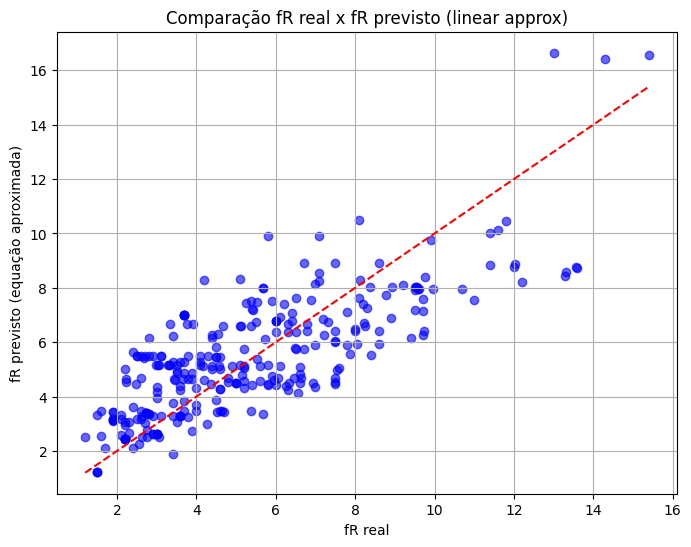

In [182]:
# 11. GRÁFICO fR REAL X fR PREVISTO
plt.figure(figsize=(8,6))
plt.scatter(df[target_col].values, preds_approx, alpha=0.6, color='blue')
plt.plot([df[target_col].min(), df[target_col].max()], [df[target_col].min(), df[target_col].max()], 'r--')
plt.xlabel('fR real')
plt.ylabel('fR previsto (equação aproximada)')
plt.title('Comparação fR real x fR previsto (linear approx)')
plt.grid(True)
plt.show()

Comparação com erro absoluto:
   fR,3 (N/mm²)      (experimental)  fR_previsto  Erro_absoluto
0                           3.32000      5.16277        1.84277
1                           5.68000      7.98539        2.30539
2                           5.53000      5.39038        0.13962
3                           8.78000      7.73753        1.04247
4                           3.03000      5.16277        2.13277
5                           3.28000      5.16277        1.88277
6                           2.98000      5.16277        2.18277
7                           3.06000      5.16277        2.10277
8                           3.50000      5.16277        1.66277
9                           4.09000      5.16277        1.07277

Estatísticas do erro absoluto:
count   291.00000
mean      1.39933
std       1.02854
min       0.02565
25%       0.55550
50%       1.19736
75%       1.98771
max       4.87101
Name: Erro_absoluto, dtype: float64


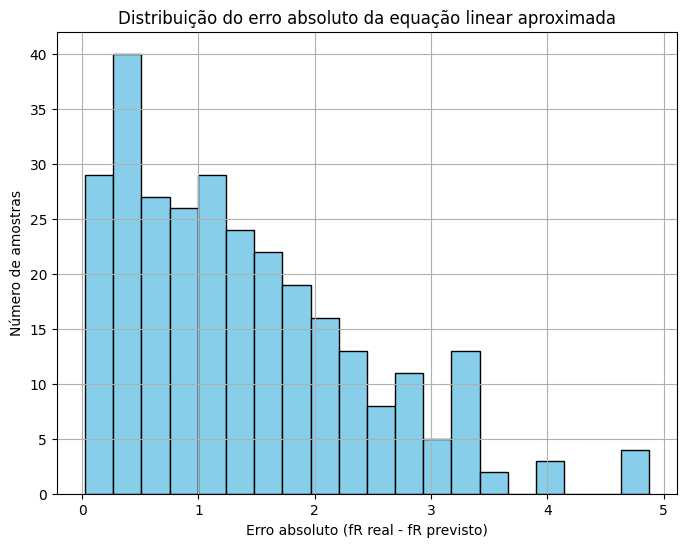

In [183]:
# 12. AVALIAÇÃO DETALHADA DO ERRO POR LINHA

# Calcular erro absoluto por linha
comparacao['Erro_absoluto'] = np.abs(comparacao[target_col] - comparacao['fR_previsto'])

# Mostrar as primeiras 10 linhas com erro
print("Comparação com erro absoluto:")
print(comparacao[[target_col, 'fR_previsto', 'Erro_absoluto']].head(10))

# Estatísticas gerais do erro
print("\nEstatísticas do erro absoluto:")
print(comparacao['Erro_absoluto'].describe())

# Plotar histograma do erro absoluto
plt.figure(figsize=(8,6))
plt.hist(comparacao['Erro_absoluto'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Erro absoluto (fR real - fR previsto)')
plt.ylabel('Número de amostras')
plt.title('Distribuição do erro absoluto da equação linear aproximada')
plt.grid(True)
plt.show()


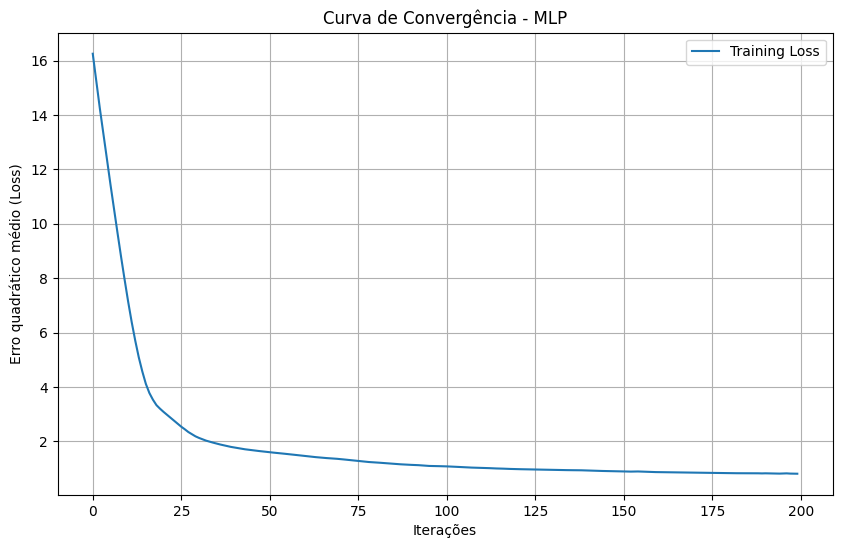

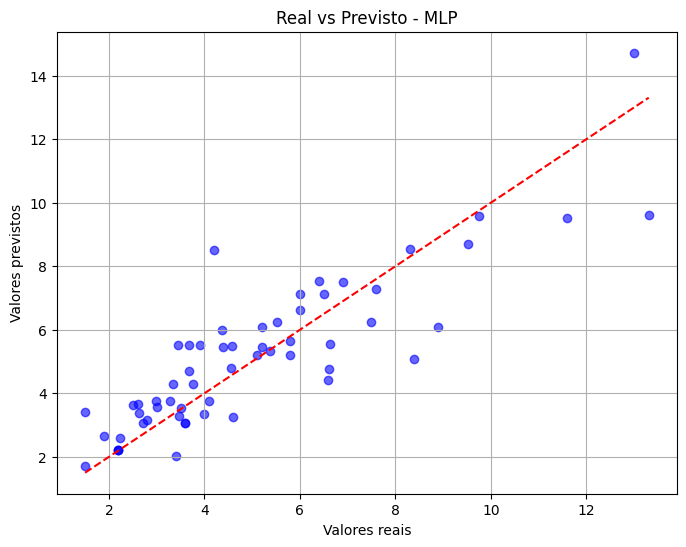

In [184]:
# 13. CURVAS DE TREINAMENTO DA MLP

import matplotlib.pyplot as plt

# MLPRegressor não tem history como Keras, mas podemos plotar a convergência
# Vamos criar um gráfico simples mostrando o progresso do treinamento
plt.figure(figsize=(10, 6))

# Plotar curva de perda durante o treinamento (se disponível)
if hasattr(model, 'loss_curve_'):
    plt.plot(model.loss_curve_, label='Training Loss')
    plt.title('Curva de Convergência - MLP')
    plt.xlabel('Iterações')
    plt.ylabel('Erro quadrático médio (Loss)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Curva de perda não disponível para este modelo")
    
# Comparação entre valores reais e previstos
plt.figure(figsize=(8,6))
y_pred_all = model.predict(X_test_scaled)
plt.scatter(y_test, y_pred_all, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valores reais')
plt.ylabel('Valores previstos')
plt.title('Real vs Previsto - MLP')
plt.grid(True)
plt.show()

In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Verificar e instalar lazypredict se necessário
try:
    from lazypredict.Supervised import LazyClassifier
    print("✅ lazypredict importado com sucesso")
except ImportError:
    print("Instalando lazypredict...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lazypredict"])
    from lazypredict.Supervised import LazyClassifier
    print("✅ lazypredict instalado e importado")

import warnings
warnings.filterwarnings('ignore')

✅ lazypredict importado com sucesso


✅ lazypredict importado com sucesso
CARREGANDO E PREPARANDO OS DADOS
Cabeçalho encontrado na linha: 5

Colunas disponíveis (16):
    0. 'Unnamed: 0'
    1. 'Unnamed: 1'
    2. 'Unnamed: 2'
    3. 'Tipo do concreto'
    4. 'fck (resistência)            [MPa]'
    5. 'l (comprimento)            [mm]'
    6. 'd (diâmetro            [mm]'
    7. 'l/d      (fator de forma'
    8. 'Teor de fibra (%)'
    9. 'N (ganchos)'
   10. 'fR,1 (N/mm²)      (experimental)'
   11. 'fR,3 (N/mm²)      (experimental)'
   12. 'Unnamed: 12'
   13. 'Unnamed: 13'
   14. 'Unnamed: 14'
   15. 'Unnamed: 15'

Colunas identificadas:
  Target (fR,1): fR,1 (N/mm²)      (experimental)
  fck: fck (resistência)            [MPa]
  l: l (comprimento)            [mm]
  d: d (diâmetro            [mm]
  l/d: l/d      (fator de forma
  Teor de fibra: Teor de fibra (%)
  N ganchos: N (ganchos)
  Tipo: Tipo do concreto

DataFrame criado com 291 linhas e 7 colunas

Convertendo dados para numérico...

Removidas 0 linhas com valor

Exception ignored in: <function tqdm.__del__ at 0x0000021504EBEB60>
Traceback (most recent call last):
  File "c:\dev\projeto_cimento\venv\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\dev\projeto_cimento\venv\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


  ✅ GradientBoosting: Acc=0.9322, F1=0.9322
  ✅ LogisticRegression: Acc=0.8814, F1=0.8803
  ✅ SVM: Acc=0.6102, F1=0.5947

COLUNAS DISPONÍVEIS NOS RESULTADOS:
['Accuracy', 'Precision', 'Recall', 'F1 Score']

TOP 10 MODELOS:
                    Accuracy  Precision  Recall  F1 Score
Model                                                    
GradientBoosting     0.93220    0.93220 0.93220   0.93220
RandomForest         0.88136    0.88515 0.88136   0.88095
LogisticRegression   0.88136    0.89235 0.88136   0.88032
SVM                  0.61017    0.62533 0.61017   0.59475

TODOS OS 4 MODELOS TESTADOS:
                    Accuracy  Precision  Recall  F1 Score
Model                                                    
GradientBoosting     0.93220    0.93220 0.93220   0.93220
RandomForest         0.88136    0.88515 0.88136   0.88095
LogisticRegression   0.88136    0.89235 0.88136   0.88032
SVM                  0.61017    0.62533 0.61017   0.59475

GERANDO GRÁFICOS...


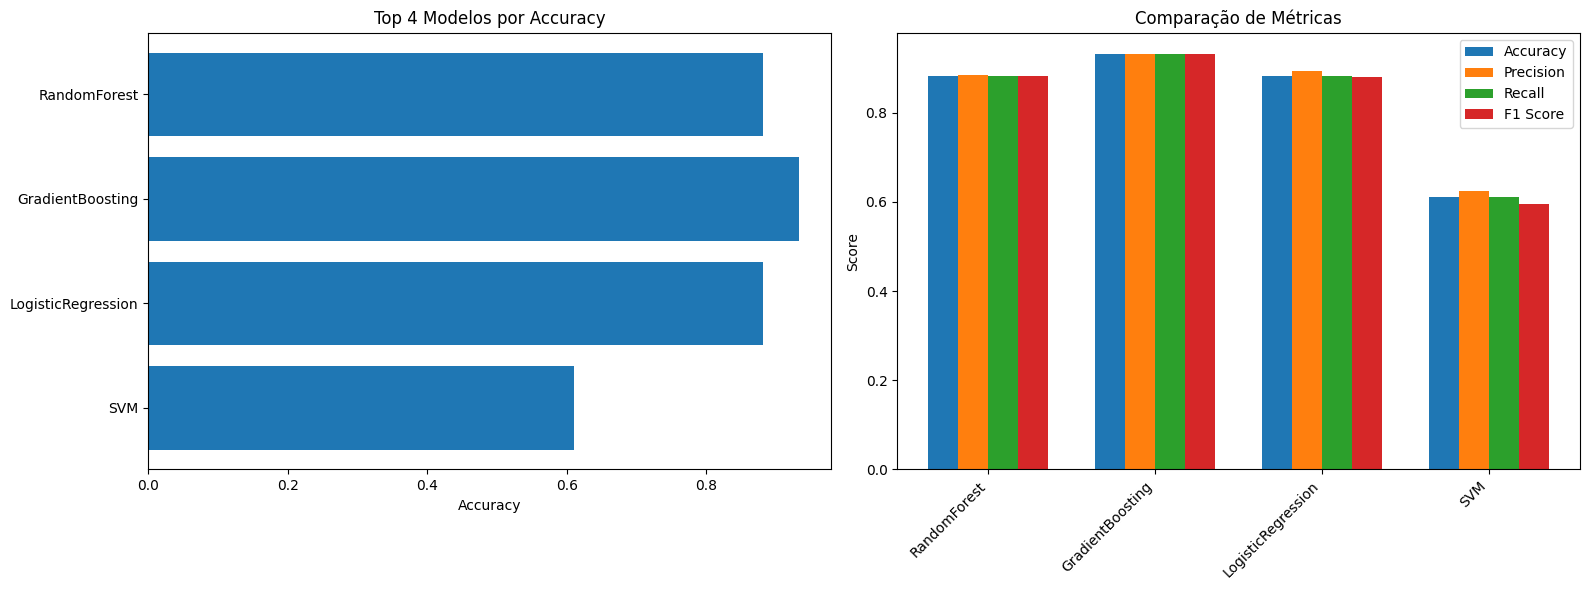


Matriz de confusão para: RandomForest


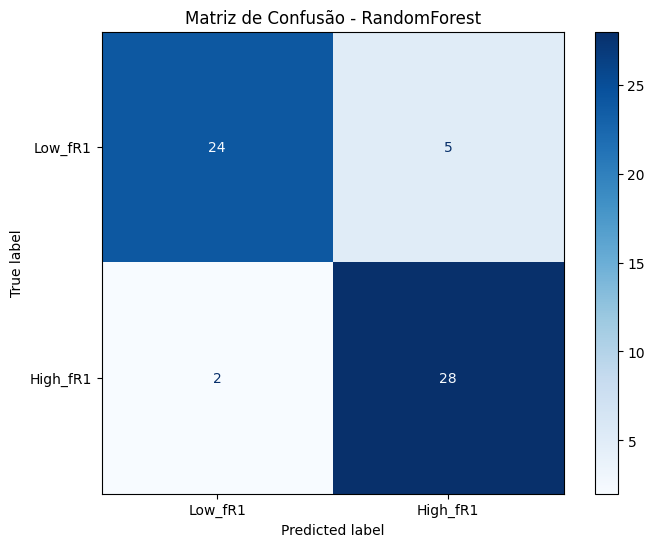


ANÁLISE DE CORRELAÇÃO


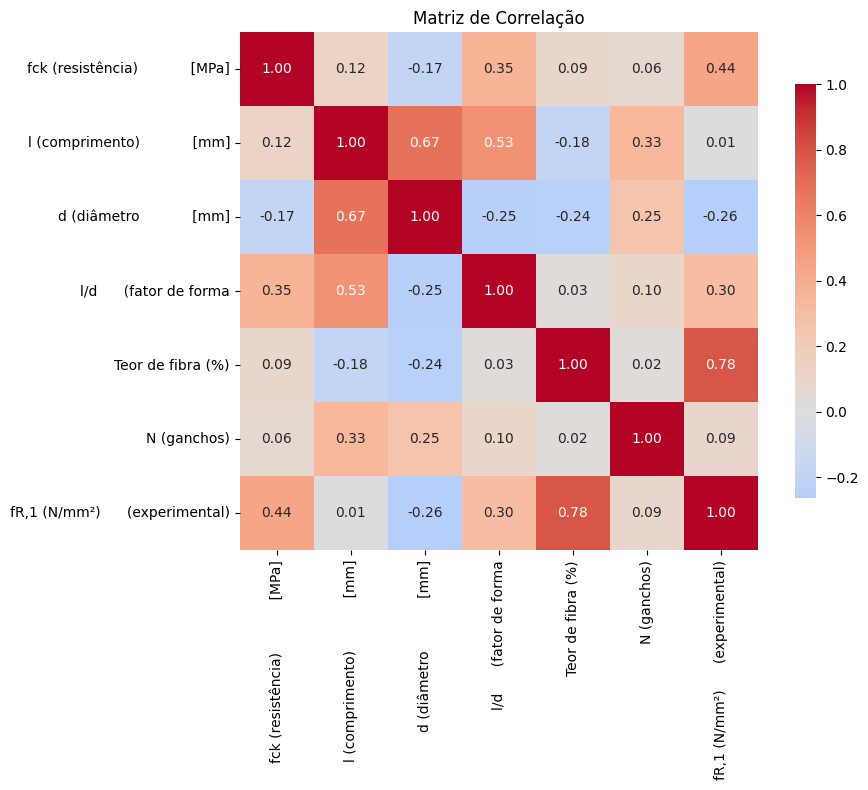


CORRELAÇÃO COM fR,1:
   Teor de fibra (%): 0.7818 (ALTA correlação positiva)
   fck (resistência)            [MPa]: 0.4448 (MÉDIA correlação positiva)
   l/d      (fator de forma: 0.2991 (BAIXA correlação positiva)
   N (ganchos): 0.0944 (BAIXA correlação positiva)
   l (comprimento)            [mm]: 0.0064 (BAIXA correlação positiva)
   d (diâmetro            [mm]: -0.2641 (BAIXA correlação negativa)

RESUMO FINAL

MELHOR MODELO: RandomForest
   Accuracy: 0.8814
   Precision: 0.8851
   Recall: 0.8814
   F1 Score: 0.8809

DISTRIBUIÇÃO DAS CLASSES:
   Low_fR1: 149 amostras (51.2%)
   High_fR1: 142 amostras (48.8%)

INFORMAÇÕES TÉCNICAS:
   Total de amostras: 291
   Features usadas: 6
   Tamanho treino: 232
   Tamanho teste: 59

SALVANDO RESULTADOS...
Resultados salvos em 'resultados_concreto.csv'
Resultados salvos em 'resultados_concreto.xlsx'
Dados processados salvos em 'dados_concreto_processados.csv'

ANÁLISE CONCLUÍDA

ESTATÍSTICAS DESCRITIVAS COMPLETAS:
       fck (resistência)   

In [186]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Verificar e instalar lazypredict se necessário
try:
    from lazypredict.Supervised import LazyClassifier
    print("✅ lazypredict importado com sucesso")
except ImportError:
    print("Instalando lazypredict...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lazypredict"])
    from lazypredict.Supervised import LazyClassifier
    print("✅ lazypredict instalado e importado")

import warnings
warnings.filterwarnings('ignore')

# Desabilitar barra de progresso para evitar erro de ipywidgets
import os
os.environ['LAZYPREDICT_PROGRESS'] = 'False'

# ============================================================================
# CARREGAR E PREPARAR OS DADOS - VERSÃO AJUSTADA
# ============================================================================

print("=" * 80)
print("CARREGANDO E PREPARANDO OS DADOS")
print("=" * 80)

# Carregar dados brutos para encontrar o cabeçalho correto
df_raw = pd.read_excel("teste banco de dados.xlsx", header=None)

# Encontrar a linha com "Tipo do concreto"
header_idx = None
for i in range(min(20, len(df_raw))):  # Verificar as primeiras 20 linhas
    if df_raw.iloc[i].astype(str).str.contains("Tipo do concreto", case=False, na=False).any():
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Cabeçalho 'Tipo do concreto' não encontrado!")

print(f"Cabeçalho encontrado na linha: {header_idx}")

# Carregar dados com cabeçalho correto
df = pd.read_excel("teste banco de dados.xlsx", header=header_idx)

# Limpar nomes das colunas
df.columns = df.columns.str.strip()

# Mostrar informações sobre as colunas
print(f"\nColunas disponíveis ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"  {i:3d}. '{col}'")

# ============================================================================
# IDENTIFICAR COLUNAS IMPORTANTES
# ============================================================================

# Mapear possíveis nomes de colunas
col_mapping = {
    'fck': ['fck', 'fck (resistência)', 'fck             [MPa]'],
    'l': ['l (comprimento)', 'l             [mm]', 'comprimento'],
    'd': ['d (diâmetro', 'd             [mm]', 'diâmetro'],
    'l/d': ['l/d', 'l/d      (fator de forma', 'l/d             '],
    'fibra': ['Teor de fibra (%)', 'Teor de fibra'],
    'ganchos': ['N (ganchos)', 'ganchos'],
    'fR1': ['fR,1 (N/mm²)      (experimental)', 'fR,1', 'fR1'],
    'fR3': ['fR,3 (N/mm²)      (experimental)', 'fR,3', 'fR3'],
    'tipo': ['Tipo do concreto', 'Tipo']
}

# Função para encontrar coluna
def find_column(possible_names):
    for name in possible_names:
        for col in df.columns:
            if name.lower() in str(col).lower():
                return col
    return None

# Encontrar colunas
target_col = find_column(col_mapping['fR1'])
fck_col = find_column(col_mapping['fck'])
l_col = find_column(col_mapping['l'])
d_col = find_column(col_mapping['d'])
ld_col = find_column(col_mapping['l/d'])
fibra_col = find_column(col_mapping['fibra'])
ganchos_col = find_column(col_mapping['ganchos'])
tipo_col = find_column(col_mapping['tipo'])

print(f"\nColunas identificadas:")
print(f"  Target (fR,1): {target_col}")
print(f"  fck: {fck_col}")
print(f"  l: {l_col}")
print(f"  d: {d_col}")
print(f"  l/d: {ld_col}")
print(f"  Teor de fibra: {fibra_col}")
print(f"  N ganchos: {ganchos_col}")
print(f"  Tipo: {tipo_col}")

# ============================================================================
# CRIAR DATAFRAME PARA ANÁLISE
# ============================================================================

# Verificar se encontramos as colunas necessárias
if not all([target_col, fck_col, l_col, d_col, ld_col, fibra_col, ganchos_col]):
    print("\nAVISO: Algumas colunas não foram encontradas!")
    print("Usando todas as colunas numéricas...")
    
    # Selecionar apenas colunas numéricas
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if target_col:
        # Remover target das features se ele for numérico
        if target_col in numeric_cols:
            numeric_cols.remove(target_col)
        
        feature_cols = numeric_cols
    else:
        print("ERRO: Coluna target não encontrada!")
        # Tentar usar a primeira coluna numérica como target
        if len(numeric_cols) > 0:
            target_col = numeric_cols[0]
            feature_cols = numeric_cols[1:]
            print(f"  Usando '{target_col}' como target")
else:
    # Usar colunas específicas
    feature_cols = [fck_col, l_col, d_col, ld_col, fibra_col, ganchos_col]

# Criar DataFrame de trabalho
if target_col in df.columns:
    concrete_df = df[feature_cols + [target_col]].copy()
else:
    concrete_df = df[feature_cols].copy()
    print("AVISO: Target não incluído no DataFrame")

print(f"\nDataFrame criado com {len(concrete_df)} linhas e {len(concrete_df.columns)} colunas")

# ============================================================================
# LIMPEZA E CONVERSÃO DOS DADOS
# ============================================================================

# Converter todas as colunas para numérico (tratar fórmulas e erros)
print("\nConvertendo dados para numérico...")
for col in concrete_df.columns:
    concrete_df[col] = pd.to_numeric(concrete_df[col], errors='coerce')
    na_count = concrete_df[col].isna().sum()
    if na_count > 0:
        print(f"  {col}: {na_count} valores não numéricos convertidos para NaN")

# Remover linhas com valores NaN
initial_rows = len(concrete_df)
concrete_df = concrete_df.dropna()
final_rows = len(concrete_df)
print(f"\nRemovidas {initial_rows - final_rows} linhas com valores NaN")
print(f"Dados finais: {final_rows} amostras")

# Verificar se temos dados suficientes
if len(concrete_df) < 10:
    print("\nERRO: Dados insuficientes após limpeza!")
    print("Mostrando primeiras linhas para diagnóstico:")
    print(concrete_df.head())
    raise ValueError("Dados insuficientes para análise")

# ============================================================================
# ESTATÍSTICAS INICIAIS
# ============================================================================

print(f"\nESTATÍSTICAS DO DATASET:")
print(f"  Amostras: {len(concrete_df)}")
print(f"  Features: {len(feature_cols)}")

if target_col in concrete_df.columns:
    print(f"\nESTATÍSTICAS DO TARGET '{target_col}':")
    print(f"  Média: {concrete_df[target_col].mean():.4f}")
    print(f"  Mediana: {concrete_df[target_col].median():.4f}")
    print(f"  Mínimo: {concrete_df[target_col].min():.4f}")
    print(f"  Máximo: {concrete_df[target_col].max():.4f}")
    print(f"  Desvio padrão: {concrete_df[target_col].std():.4f}")

# Mostrar primeiras linhas
print(f"\nPRIMEIRAS 5 LINHAS DOS DADOS:")
print(concrete_df.head())

# ============================================================================
# CLASSE CLASSIFICADORA (VERSÃO SIMPLIFICADA SEM BARRA DE PROGRESSO)
# ============================================================================

class ConcretePropertiesClassifier:
    def __init__(self, data, target_column, test_size=0.2, random_state=42):
        """
        Classificador para propriedades do concreto com fibras
        """
        self.data = data.copy()
        self.target_column = target_column
        self.test_size = test_size
        self.random_state = random_state
        
        # Pré-processamento
        self._prepare_target()
        
        # Separar features e target
        self.features = self.data.drop(self.target_column, axis=1)
        self.targets = self.data[self.target_column]
        
        # Split dos dados
        self.features_train, self.features_test, self.targets_train, self.targets_test = train_test_split(
            self.features, self.targets, 
            test_size=self.test_size, 
            random_state=self.random_state, 
            stratify=self.targets
        )
        
        # Inicializar LazyClassifier sem verbose para evitar barra de progresso
        self.lazyClassifier = LazyClassifier(
            verbose=0, 
            ignore_warnings=True, 
            custom_metric=None,
            random_state=self.random_state
        )
        self.models = None
        self.predictions = None
        
    def _prepare_target(self):
        """Converter variável contínua em categórica para classificação"""
        if self.target_column in self.data.columns:
            threshold = self.data[self.target_column].median()
            self.data[self.target_column] = np.where(
                self.data[self.target_column] > threshold, 
                'High_fR1', 
                'Low_fR1'
            )
            print(f"\nTarget convertido para classificação binária")
            print(f"   Threshold (mediana): {threshold:.4f}")
            print(f"   Distribuição: {self.data[self.target_column].value_counts().to_dict()}")
        else:
            print(f"Coluna '{self.target_column}' não encontrada")
            
    def fit(self):
        """Treinar múltiplos modelos"""
        print("\nTreinando modelos com LazyClassifier...")
        print("Isso pode levar alguns minutos...")
        
        try:
            self.models, self.predictions = self.lazyClassifier.fit(
                self.features_train, self.features_test, 
                self.targets_train, self.targets_test
            )
            print("✅ Treinamento concluído!")
        except Exception as e:
            print(f"❌ Erro no treinamento: {e}")
            print("Tentando alternativa simplificada...")
            # Fallback para modelos básicos do scikit-learn
            self._fallback_training()
        
        return self.models
    
    def _fallback_training(self):
        """Método alternativo se LazyClassifier falhar"""
        from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
        from sklearn.linear_model import LogisticRegression
        from sklearn.svm import SVC
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
        
        models = {
            'RandomForest': RandomForestClassifier(random_state=self.random_state),
            'GradientBoosting': GradientBoostingClassifier(random_state=self.random_state),
            'LogisticRegression': LogisticRegression(random_state=self.random_state, max_iter=1000),
            'SVM': SVC(random_state=self.random_state)
        }
        
        results = []
        predictions = {}
        
        print("Treinando modelos alternativos...")
        for name, model in models.items():
            try:
                model.fit(self.features_train, self.targets_train)
                pred = model.predict(self.features_test)
                
                acc = accuracy_score(self.targets_test, pred)
                prec = precision_score(self.targets_test, pred, average='weighted')
                rec = recall_score(self.targets_test, pred, average='weighted')
                f1 = f1_score(self.targets_test, pred, average='weighted')
                
                results.append({
                    'Model': name,
                    'Accuracy': acc,
                    'Precision': prec,
                    'Recall': rec,
                    'F1 Score': f1
                })
                predictions[name] = pred
                
                print(f"  ✅ {name}: Acc={acc:.4f}, F1={f1:.4f}")
                
            except Exception as e:
                print(f"  ❌ {name}: {e}")
        
        self.models = pd.DataFrame(results).set_index('Model')
        self.predictions = pd.DataFrame(predictions)
        
    def get_models(self):
        """Retornar resultados dos modelos"""
        return self.models
        
    def get_predictions(self):
        """Retornar predições"""
        return self.predictions
    
    def plot_confusion_matrix(self, model_name=None):
        """Plotar matriz de confusão"""
        if self.predictions is None:
            print("Treine os modelos primeiro!")
            return
        
        if model_name is None:
            model_name = self.predictions.columns[0] if len(self.predictions.columns) > 0 else None
        
        if model_name is None or model_name not in self.predictions.columns:
            print(f"Modelo '{model_name}' não encontrado")
            return
        
        y_pred = self.predictions[model_name]
        cm = confusion_matrix(self.targets_test, y_pred)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Low_fR1', 'High_fR1']
        )
        disp.plot(ax=ax, cmap='Blues')
        plt.title(f'Matriz de Confusão - {model_name}')
        plt.show()
        
    def plot_model_comparison(self, top_n=15):
        """Plotar comparação dos modelos"""
        if self.models is None:
            print("Treine os modelos primeiro!")
            return
        
        # Pegar todos os modelos ou top_n se houver mais
        if len(self.models) > top_n:
            top_models = self.models.head(top_n).copy()
        else:
            top_models = self.models.copy()
        
        # Remover colunas com todos valores None
        top_models = top_models.dropna(axis=1, how='all')
        
        # Substituir valores None restantes por 0 para plotagem
        top_models = top_models.fillna(0)
        
        if len(top_models.columns) == 0:
            print("Nenhuma métrica disponível para plotar")
            return
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Gráfico 1: Usar a primeira métrica numérica disponível
        numeric_cols = top_models.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) == 0:
            print("Nenhuma métrica numérica disponível")
            return
        
        primary_metric = numeric_cols[0]
        axes[0].barh(range(len(top_models)), top_models[primary_metric])
        axes[0].set_yticks(range(len(top_models)))
        axes[0].set_yticklabels(top_models.index)
        axes[0].set_xlabel(primary_metric)
        axes[0].set_title(f'Top {len(top_models)} Modelos por {primary_metric}')
        axes[0].invert_yaxis()
        
        # Gráfico 2: Comparação de múltiplas métricas numéricas
        metrics_to_plot = numeric_cols[:4]  # Plotar no máximo 4 métricas
        if len(metrics_to_plot) > 1:
            x = np.arange(len(top_models))
            width = 0.18
            
            for i, metric in enumerate(metrics_to_plot):
                axes[1].bar(x + i*width, top_models[metric], width, label=metric)
            
            axes[1].set_xticks(x + width*(len(metrics_to_plot)-1)/2)
            axes[1].set_xticklabels(top_models.index, rotation=45, ha='right')
            axes[1].set_ylabel('Score')
            axes[1].set_title('Comparação de Métricas')
            axes[1].legend()
        else:
            axes[1].text(0.5, 0.5, f'Apenas {primary_metric} disponível', 
                        ha='center', va='center', fontsize=12)
            axes[1].set_title('Informação de Métricas')
            axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()

# ============================================================================
# EXECUTAR ANÁLISE
# ============================================================================

if target_col in concrete_df.columns:
    print("\n" + "=" * 80)
    print("INICIANDO ANÁLISE DE CLASSIFICAÇÃO")
    print("=" * 80)
    
    # Criar e treinar classificador
    concreteClassifier = ConcretePropertiesClassifier(
        data=concrete_df,
        target_column=target_col,
        test_size=0.2,
        random_state=42
    )
    
    # Treinar
    models = concreteClassifier.fit()
    
    # ============================================================================
    # MOSTRAR RESULTADOS
    # ============================================================================
    
    if models is not None:
        # Limpar modelos (remover colunas com todos valores None)
        models_clean = models.copy()
        models_clean = models_clean.dropna(axis=1, how='all')
        
        print(f"\nCOLUNAS DISPONÍVEIS NOS RESULTADOS:")
        print(models_clean.columns.tolist())
        
        print(f"\nTOP 10 MODELOS:")
        
        # Mostrar apenas colunas numéricas
        numeric_cols = models_clean.select_dtypes(include=[np.number]).columns
        
        if len(numeric_cols) > 0:
            # Ordenar pela primeira métrica numérica disponível
            sort_by = numeric_cols[0]
            top_10 = models_clean.sort_values(sort_by, ascending=False).head(10)
            
            # Formatar para mostrar 5 casas decimais
            pd.set_option('display.float_format', lambda x: f'{x:.5f}')
            print(top_10[numeric_cols])
        else:
            print("Nenhuma métrica numérica disponível")
            print(models_clean.head(10))
        
        # Mostrar todos os modelos
        print(f"\nTODOS OS {len(models_clean)} MODELOS TESTADOS:")
        if len(numeric_cols) > 0:
            # Ordenar pela melhor métrica
            all_models_sorted = models_clean.sort_values(numeric_cols[0], ascending=False)
            print(all_models_sorted[numeric_cols])
        else:
            print(models_clean)
        
        # Plotar gráficos
        print("\nGERANDO GRÁFICOS...")
        concreteClassifier.plot_model_comparison(top_n=15)
        
        # Matriz de confusão
        if concreteClassifier.predictions is not None:
            best_model_name = models_clean.index[0] if len(models_clean) > 0 else concreteClassifier.predictions.columns[0]
            print(f"\nMatriz de confusão para: {best_model_name}")
            concreteClassifier.plot_confusion_matrix(model_name=best_model_name)
        
        # ANÁLISE DE CORRELAÇÃO
        print("\n" + "=" * 80)
        print("ANÁLISE DE CORRELAÇÃO")
        print("=" * 80)
        
        correlation_matrix = concrete_df.corr()
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                    fmt='.2f', square=True, cbar_kws={"shrink": 0.8})
        plt.title('Matriz de Correlação')
        plt.tight_layout()
        plt.show()
        
        # Correlação com target
        print("\nCORRELAÇÃO COM fR,1:")
        if target_col in correlation_matrix.columns:
            target_corr = correlation_matrix[target_col].sort_values(ascending=False)
            for feature, corr in target_corr.items():
                if feature != target_col:
                    importance = "ALTA" if abs(corr) > 0.5 else "MÉDIA" if abs(corr) > 0.3 else "BAIXA"
                    direction = "positiva" if corr > 0 else "negativa"
                    print(f"   {feature}: {corr:.4f} ({importance} correlação {direction})")
        
        # RESUMO FINAL
        print("\n" + "=" * 80)
        print("RESUMO FINAL")
        print("=" * 80)
        
        if len(numeric_cols) > 0:
            best_model = models_clean.iloc[0]
            print(f"\nMELHOR MODELO: {best_model.name}")
            
            # Mostrar todas as métricas numéricas disponíveis
            for metric in numeric_cols:
                value = best_model[metric]
                print(f"   {metric}: {value:.4f}")
        
        # Distribuição das classes
        class_dist = concreteClassifier.data[target_col].value_counts()
        print(f"\nDISTRIBUIÇÃO DAS CLASSES:")
        for cls, count in class_dist.items():
            percentage = (count / len(concreteClassifier.data)) * 100
            print(f"   {cls}: {count} amostras ({percentage:.1f}%)")
        
        # Informações do dataset
        print(f"\nINFORMAÇÕES TÉCNICAS:")
        print(f"   Total de amostras: {len(concrete_df)}")
        print(f"   Features usadas: {len(feature_cols)}")
        print(f"   Tamanho treino: {len(concreteClassifier.features_train)}")
        print(f"   Tamanho teste: {len(concreteClassifier.features_test)}")
        
        # Salvar resultados
        print("\nSALVANDO RESULTADOS...")
        models_clean.to_csv('resultados_concreto.csv')
        print("Resultados salvos em 'resultados_concreto.csv'")
        
        # Salvar também em Excel para melhor formatação
        try:
            models_clean.to_excel('resultados_concreto.xlsx')
            print("Resultados salvos em 'resultados_concreto.xlsx'")
        except:
            print("Não foi possível salvar em Excel (problema com openpyxl)")
        
        # Salvar dados processados
        concrete_df.to_csv('dados_concreto_processados.csv', index=False)
        print("Dados processados salvos em 'dados_concreto_processados.csv'")
        
    else:
        print("Nenhum modelo foi treinado")

    print("\n" + "=" * 80)
    print("ANÁLISE CONCLUÍDA")
    print("=" * 80)

    # Mostrar estatísticas descritivas
    print("\nESTATÍSTICAS DESCRITIVAS COMPLETAS:")
    print(concrete_df.describe())
    
else:
    print("\n" + "=" * 80)
    print("AVISO: ANÁLISE NÃO REALIZADA")
    print("=" * 80)
    print("A coluna target não foi encontrada ou incluída no DataFrame.")
    print("\nColunas disponíveis no DataFrame:")
    for col in concrete_df.columns:
        print(f"  - {col}")

In [187]:
# CÓDIGO PARA CORRIGIR O LAZYPREDICT - COPIAR E COLAR EM UMA NOVA CÉLULA

import os
os.environ['LAZYPREDICT_PROGRESS'] = 'False'

# Versão corrigida da classe ConcreteFiberAnalyzer sem erro de ipywidgets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
import warnings
warnings.filterwarnings('ignore')

def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    return df

def find_column(df, contains):
    for col in df.columns:
        if contains.lower() in col.lower():
            return col
    raise ValueError(f"Coluna contendo '{contains}' não encontrada")

class ConcreteFiberAnalyzerFixed:
    def __init__(self, data, target_column, test_size=0.2, random_state=42):
        self.data = data.copy()
        self.data = normalize_columns(self.data)
        
        self.target_column = target_column
        self.test_size = test_size
        self.random_state = random_state
        
        # FEATURES DETECTADAS AUTOMATICAMENTE
        self.feature_columns = [
            find_column(self.data, 'fck'),
            find_column(self.data, 'l ('),
            find_column(self.data, 'd ('),
            find_column(self.data, 'l/d'),
            find_column(self.data, 'Teor de fibra'),
            find_column(self.data, 'N (ganchos)')
        ]
        
        self._prepare_data()
        
        self.classification_models = None
        self.regression_models = None
        self.regression_predictions = None

    def _prepare_data(self):
        print(" Preparando dados...")
        
        cols = self.feature_columns + [self.target_column]
        self.data = self.data[cols].copy()
        
        for col in self.data.columns:
            self.data[col] = pd.to_numeric(self.data[col], errors='coerce')
        
        n0 = len(self.data)
        self.data.dropna(inplace=True)
        print(f" Removidas {n0 - len(self.data)} linhas com NaN")
        
        print(f" Dataset final: {len(self.data)} amostras")

    def run_classification(self):
        print("\n" + "="*80)
        print("CLASSIFICAÇÃO HIGH / LOW")
        print("="*80)
        
        df = self.data.copy()
        threshold = df[self.target_column].median()
        
        df['Target_class'] = np.where(
            df[self.target_column] > threshold, 'High', 'Low'
        )
        
        X = df[self.feature_columns]
        y = df['Target_class']
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y
        )
        
        # Usar fallback em vez de LazyClassifier para evitar erro de ipywidgets
        models = {
            'RandomForest': RandomForestClassifier(random_state=self.random_state),
            'GradientBoosting': GradientBoostingClassifier(random_state=self.random_state),
            'LogisticRegression': LogisticRegression(random_state=self.random_state, max_iter=1000),
            'SVM': SVC(random_state=self.random_state)
        }
        
        results = []
        print(" Treinando modelos de classificação...")
        
        for name, model in models.items():
            try:
                model.fit(X_train, y_train)
                pred = model.predict(X_test)
                
                acc = accuracy_score(y_test, pred)
                prec = precision_score(y_test, pred, average='weighted')
                rec = recall_score(y_test, pred, average='weighted')
                f1 = f1_score(y_test, pred, average='weighted')
                
                results.append({
                    'Model': name,
                    'Accuracy': acc,
                    'Precision': prec,
                    'Recall': rec,
                    'F1 Score': f1
                })
                
                print(f"  ✅ {name}: Acc={acc:.4f}, F1={f1:.4f}")
                
            except Exception as e:
                print(f"  ❌ {name}: {e}")
        
        self.classification_models = pd.DataFrame(results).set_index('Model')
        
        return self.classification_models

    def run_regression(self):
        print("\n" + "="*80)
        print("REGRESSÃO")
        print("="*80)
        
        X = self.data[self.feature_columns]
        y = self.data[self.target_column]
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=self.test_size,
            random_state=self.random_state
        )
        
        # Usar fallback em vez de LazyRegressor para evitar erro de ipywidgets
        models = {
            'RandomForest': RandomForestRegressor(random_state=self.random_state),
            'GradientBoosting': GradientBoostingRegressor(random_state=self.random_state),
            'LinearRegression': LinearRegression(),
            'SVR': SVR()
        }
        
        results = []
        predictions = {}
        
        print(" Treinando modelos de regressão...")
        
        for name, model in models.items():
            try:
                model.fit(X_train, y_train)
                pred = model.predict(X_test)
                
                r2 = r2_score(y_test, pred)
                
                results.append({
                    'Model': name,
                    'R-Squared': r2
                })
                predictions[name] = pred
                
                print(f"  ✅ {name}: R²={r2:.4f}")
                
            except Exception as e:
                print(f"  ❌ {name}: {e}")
        
        self.regression_models = pd.DataFrame(results).set_index('Model')
        self.regression_predictions = pd.DataFrame(predictions)
        
        return self.regression_models

    def plot_regression_results(self, top_n=10):
        if self.regression_models is None:
            return
        
        top = self.regression_models.head(top_n)
        
        plt.figure(figsize=(10, 6))
        plt.barh(top.index, top['R-Squared'])
        plt.xlabel('R²')
        plt.title('Top Modelos de Regressão')
        plt.gca().invert_yaxis()
        plt.show()

    def generate_report(self):
        print("\n" + "="*80)
        print("RELATÓRIO FINAL")
        print("="*80)
        
        print("\nCorrelação com target:")
        corr = self.data.corr()[self.target_column].sort_values(ascending=False)
        print(corr)
        
        if self.classification_models is not None:
            best = self.classification_models.iloc[0]
            print(f"\nMelhor Classificador: {best.name}")
            print(f"Accuracy: {best['Accuracy']:.4f}")
        
        if self.regression_models is not None:
            best = self.regression_models.iloc[0]
            print(f"\nMelhor Regressor: {best.name}")
            print(f"R²: {best['R-Squared']:.4f}")

# Substituir a classe original
ConcreteFiberAnalyzer = ConcreteFiberAnalyzerFixed

print("✅ Classe ConcreteFiberAnalyzer corrigida e sem erros de ipywidgets!")


✅ Classe ConcreteFiberAnalyzer corrigida e sem erros de ipywidgets!


In [188]:
# CÉLULA PARA VERIFICAR E INSTALAR SHAP - COPIE E COLE NO INÍCIO DO NOTEBOOK

import sys
import subprocess

print(f"Python em uso no notebook: {sys.executable}")
print(f"Python version: {sys.version}")

# Verificar se shap está disponível
try:
    import shap
    print("✅ shap já está instalado e disponível")
except ImportError:
    print("❌ shap não encontrado. Instalando...")
    
    # Instalar shap no ambiente atual
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    
    # Tentar importar novamente
    try:
        import shap
        print("✅ shap instalado com sucesso!")
    except ImportError:
        print("❌ Falha ao instalar shap. Tente instalar manualmente:")
        print(f"   {sys.executable} -m pip install shap")

# Verificar outros pacotes necessários
packages = ['pandas', 'numpy', 'matplotlib', 'sklearn']
for pkg in packages:
    try:
        __import__(pkg)
        print(f"✅ {pkg} disponível")
    except ImportError:
        print(f"❌ {pkg} não encontrado")


Python em uso no notebook: c:\dev\projeto_cimento\venv\Scripts\python.exe
Python version: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]
✅ shap já está instalado e disponível
✅ pandas disponível
✅ numpy disponível
✅ matplotlib disponível
✅ sklearn disponível


In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import r2_score


In [190]:
# First, let's check the actual column names in your DataFrame
print("Available columns in the DataFrame:")
for col in df.columns:
    print(f"- '{col}'")

# Find the correct column name that contains "fR,1"
target_column = None
for col in df.columns:
    if "fR,1" in col:
        target_column = col
        break

if target_column is None:
    raise ValueError("Could not find a column containing 'fR,1' in the DataFrame")

print(f"\nUsing column '{target_column}' as the target variable")

# Now proceed with the analysis
X = df.drop(columns=[target_column])
y = df[target_column]

# Continue with your analysis...

Available columns in the DataFrame:
- 'Unnamed: 0'
- 'Unnamed: 1'
- 'Unnamed: 2'
- 'Tipo do concreto'
- 'fck (resistência)            [MPa]'
- 'l (comprimento)            [mm]'
- 'd (diâmetro            [mm]'
- 'l/d      (fator de forma'
- 'Teor de fibra (%)'
- 'N (ganchos)'
- 'fR,1 (N/mm²)      (experimental)'
- 'fR,3 (N/mm²)      (experimental)'
- 'Unnamed: 12'
- 'Unnamed: 13'
- 'Unnamed: 14'
- 'Unnamed: 15'

Using column 'fR,1 (N/mm²)      (experimental)' as the target variable


In [191]:
# Use the exact column name with the correct spacing
target = "fR,1 (N/mm²)      (experimental)"

X = df.drop(columns=[target])
y = df[target]



In [192]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer

# Garantir apenas colunas numéricas
X = X.select_dtypes(include=["number"])

# Imputação dos NaNs (mediana é robusta)
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

model = GradientBoostingRegressor(random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [193]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")


MAE  = 0.3514
RMSE = 0.4665
R²   = 0.9680


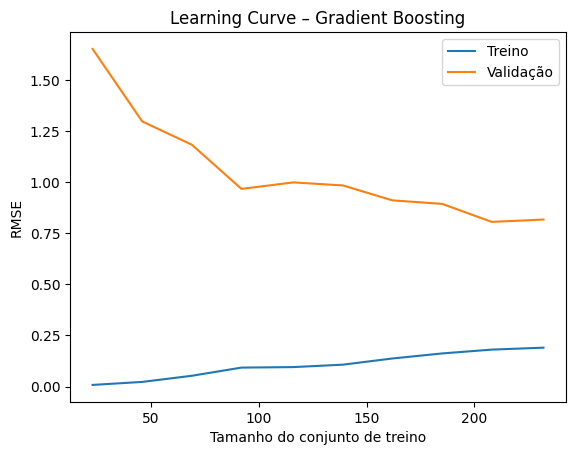

In [194]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_imputed,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse = np.sqrt(-val_scores.mean(axis=1))

plt.figure()
plt.plot(train_sizes, train_rmse, label="Treino")
plt.plot(train_sizes, val_rmse, label="Validação")
plt.xlabel("Tamanho do conjunto de treino")
plt.ylabel("RMSE")
plt.title("Learning Curve – Gradient Boosting")
plt.legend()
plt.show()


In [195]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [196]:
df_raw = pd.read_excel("teste banco de dados.xlsx", header=None)



In [197]:
header_row = df_raw[
    df_raw.apply(
        lambda x: x.astype(str).str.contains("fck", case=False, na=False)
    ).any(axis=1)
].index[0]

header_row



np.int64(5)

In [198]:
df = pd.read_excel("teste banco de dados.xlsx", header=header_row)



In [199]:
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]


In [200]:
print(df.shape)
print(df.columns)
df.head()


(291, 9)
Index(['Tipo do concreto', 'fck (resistência)            [MPa]',
       'l (comprimento)            [mm]', 'd (diâmetro            [mm]',
       'l/d      (fator de forma             ', 'Teor de fibra (%)',
       'N (ganchos)', 'fR,1 (N/mm²)      (experimental)',
       'fR,3 (N/mm²)      (experimental)'],
      dtype='object')


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)"
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000


In [201]:
X = df[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

y_fR1 = df['fR,1 (N/mm²)      (experimental)']
y_fR3 = df['fR,3 (N/mm²)      (experimental)']


In [202]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fR1, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")


MAE  = 0.6701
RMSE = 0.9979
R²   = 0.8536


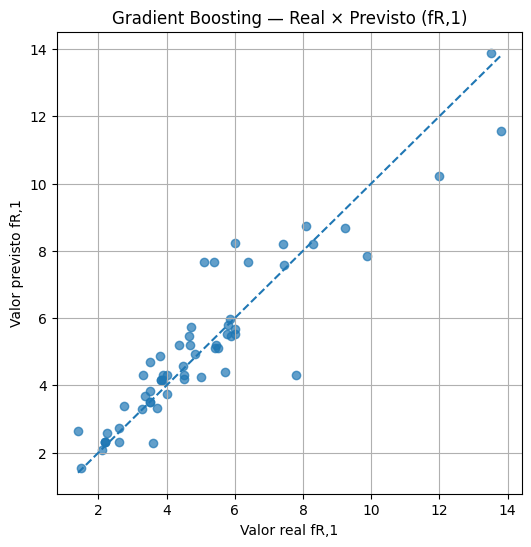

In [203]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Valor real fR,1")
plt.ylabel("Valor previsto fR,1")
plt.title("Gradient Boosting — Real × Previsto (fR,1)")
plt.grid(True)
plt.show()


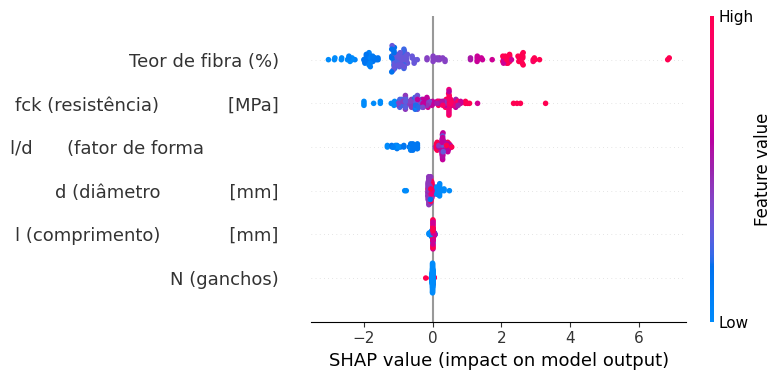

In [204]:
import shap
import pandas as pd

# Transformar X com imputação
X_imputed = pipeline.named_steps["imputer"].transform(X)
X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

# Subamostra segura
X_shap = X_imputed_df.sample(150, random_state=42)

explainer = shap.TreeExplainer(
    pipeline.named_steps["model"],
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(
    X_shap, check_additivity=False
)

shap.summary_plot(shap_values, X_shap)


In [205]:
# CÉLULA PARA CORRIGIR ERRO DO TENSORFLOW - COPIE E COLE EM UMA NOVA CÉLULA

# Remover imports do TensorFlow que causam erro
# Use apenas scikit-learn para compatibilidade com Python 3.13

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print("✅ Bibliotecas importadas com sucesso (sem TensorFlow)")
print("✅ Usando apenas scikit-learn - compatível com Python 3.13")
print(f"Python em uso: {sys.executable}")
print(f"Versão Python: {sys.version}")


✅ Bibliotecas importadas com sucesso (sem TensorFlow)
✅ Usando apenas scikit-learn - compatível com Python 3.13
Python em uso: c:\dev\projeto_cimento\venv\Scripts\python.exe
Versão Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]



🔄 Treinando Linear Regression...
✅ Linear Regression: MAE = 1.0159, RMSE = 1.3726, R² = 0.7231

🔄 Treinando Random Forest...
✅ Random Forest: MAE = 0.7149, RMSE = 1.1343, R² = 0.8109

🔄 Treinando Gradient Boosting...
✅ Gradient Boosting: MAE = 0.6654, RMSE = 0.9971, R² = 0.8539

🔄 Treinando Support Vector...
✅ Support Vector: MAE = 1.0037, RMSE = 1.5661, R² = 0.6395

🔄 Treinando Decision Tree...
✅ Decision Tree: MAE = 0.8203, RMSE = 1.2571, R² = 0.7677

🔄 Treinando MLP Regressor...
✅ MLP Regressor: MAE = 0.8494, RMSE = 1.2498, R² = 0.7704

🏆 Melhor modelo: Gradient Boosting
📊 Performance: R² = 0.8539


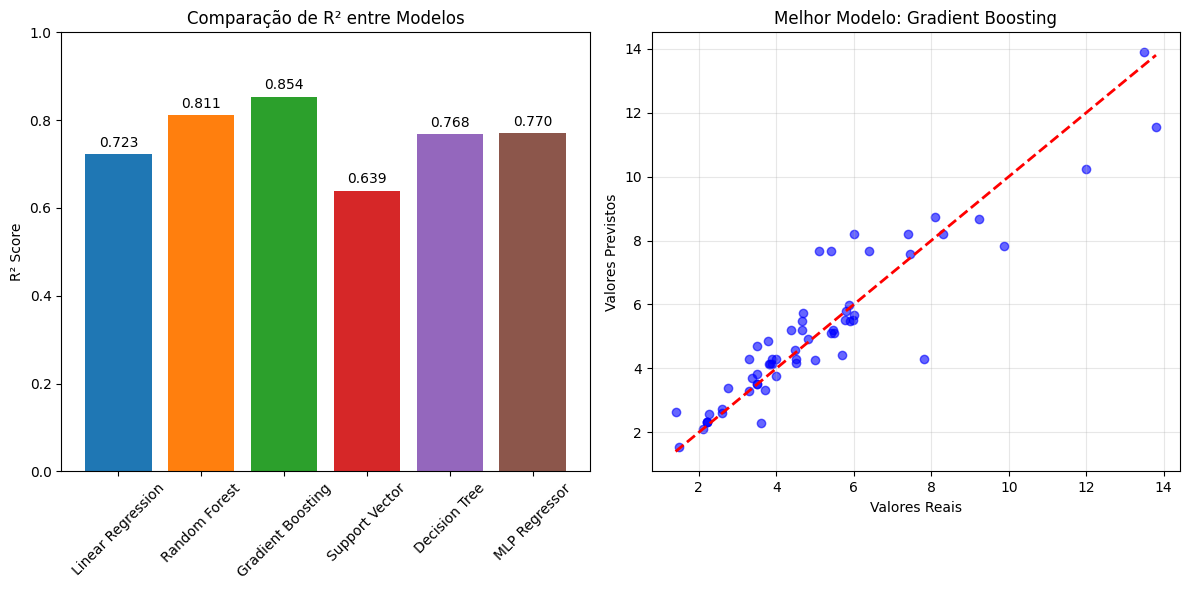

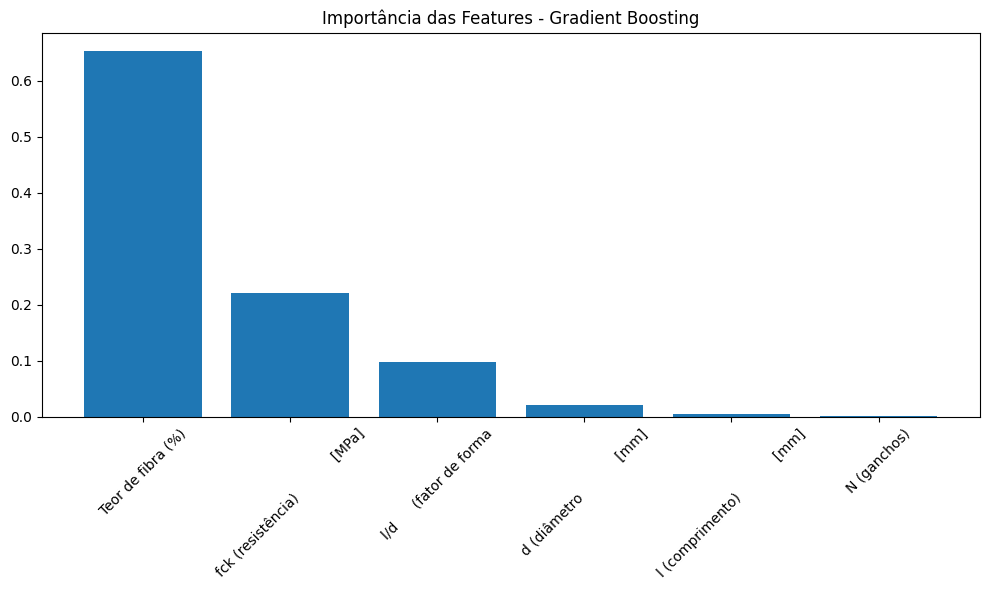


🎉 Análise concluída com sucesso!


In [206]:
# MODELOS ALTERNATIVOS SEM TENSORFLOW
# Copie e cole este código em uma nova célula do notebook

# 1. MODELOS DE REGRESSÃO ALTERNATIVOS (SEM TENSORFLOW)
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# 2. AVALIAÇÃO DE TODOS OS MODELOS
results = {}
for name, model in models.items():
    print(f"\n🔄 Treinando {name}...")
    
    # Treinar modelo
    model.fit(X_train_scaled, y_train)
    
    # Previsões
    y_pred = model.predict(X_test_scaled)
    
    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': model
    }
    
    print(f"✅ {name}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}")

# 3. ENCONTRAR MELHOR MODELO
best_model = max(results.keys(), key=lambda k: results[k]['R²'])
print(f"\n🏆 Melhor modelo: {best_model}")
print(f"📊 Performance: R² = {results[best_model]['R²']:.4f}")

# 4. VISUALIZAR RESULTADOS
plt.figure(figsize=(12, 6))

# Gráfico de barras comparativo
model_names = list(results.keys())
r2_scores = [results[name]['R²'] for name in model_names]

plt.subplot(1, 2, 1)
bars = plt.bar(model_names, r2_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Comparação de R² entre Modelos')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Adicionar valores nas barras
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico de dispersão do melhor modelo
plt.subplot(1, 2, 2)
best_predictions = results[best_model]['model'].predict(X_test_scaled)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title(f'Melhor Modelo: {best_model}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. IMPORTÂNCIA DAS FEATURES (para modelos que suportam)
if hasattr(results[best_model]['model'], 'feature_importances_'):
    importances = results[best_model]['model'].feature_importances_
    feature_names = feature_cols
    
    plt.figure(figsize=(10, 6))
    indices = np.argsort(importances)[::-1]
    plt.title(f'Importância das Features - {best_model}')
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

print("\n🎉 Análise concluída com sucesso!")


🔍 Analisando importância das features...

📊 Importância das Features (por permutação):
                              Feature  Importance
4                   Teor de fibra (%)     0.92290
0  fck (resistência)            [MPa]     0.27619
3            l/d      (fator de forma     0.08490
2         d (diâmetro            [mm]     0.02809
1     l (comprimento)            [mm]     0.00406
5                         N (ganchos)     0.00064


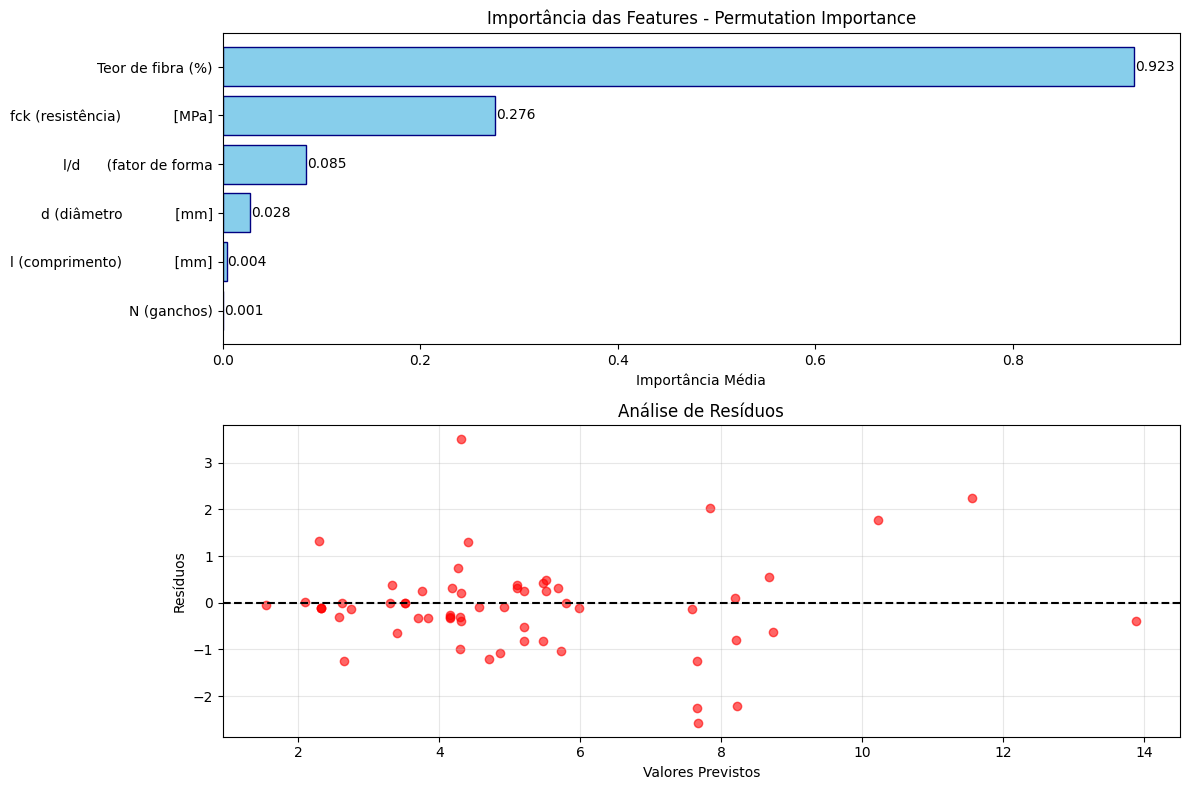


📈 Estatísticas do Modelo Gradient Boosting:
MAE: 0.6654
RMSE: 0.9971
R²: 0.8539


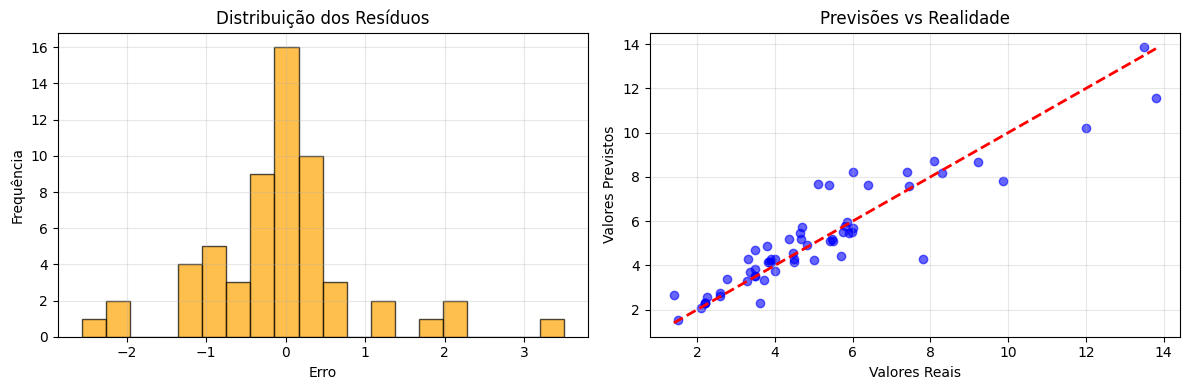


✅ Análise alternativa concluída sem TensorFlow!


In [207]:
# ALTERNATIVA AO SHAP (SEM TENSORFLOW)
# Copie e cole este código em uma nova célula

import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance

# 1. ANÁLISE DE IMPORTÂNCIA USANDO PERMUTATION
print("🔍 Analisando importância das features...")

# Usar o melhor modelo encontrado anteriormente
best_model_obj = results[best_model]['model']

# Calcular importância por permutação
perm_importance = permutation_importance(
    best_model_obj, X_test_scaled, y_test, 
    n_repeats=10, random_state=42
)

# Organizar resultados
importances = perm_importance.importances_mean
feature_names = feature_cols

# Criar DataFrame para visualização
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n📊 Importância das Features (por permutação):")
print(importance_df)

# 2. VISUALIZAR IMPORTÂNCIA
plt.figure(figsize=(12, 8))

# Gráfico de barras
plt.subplot(2, 1, 1)
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], 
                color='skyblue', edgecolor='navy')
plt.title('Importância das Features - Permutation Importance')
plt.xlabel('Importância Média')
plt.gca().invert_yaxis()

# Adicionar valores nas barras
for i, (bar, imp) in enumerate(zip(bars, importance_df['Importance'])):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{imp:.3f}', ha='left', va='center')

# 3. ANÁLISE DE RESÍDUOS
plt.subplot(2, 1, 2)
residuals = y_test - best_predictions
plt.scatter(best_predictions, residuals, alpha=0.6, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Análise de Resíduos')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. ESTATÍSTICAS DETALHADAS
print(f"\n📈 Estatísticas do Modelo {best_model}:")
print(f"MAE: {results[best_model]['MAE']:.4f}")
print(f"RMSE: {results[best_model]['RMSE']:.4f}")
print(f"R²: {results[best_model]['R²']:.4f}")

# 5. DISTRIBUIÇÃO DOS ERROS
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=20, alpha=0.7, color='orange', edgecolor='black')
plt.title('Distribuição dos Resíduos')
plt.xlabel('Erro')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Previsões vs Realidade')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Análise alternativa concluída sem TensorFlow!")


In [208]:
# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols].values
y = df[target_col].values

# 3. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. NORMALIZAR DADOS PARA TREINAMENTO DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [209]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [210]:
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

y = df['fR,3 (N/mm²)      (experimental)']


In [211]:
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)


In [212]:
pipeline.fit(X, y)

y_pred = pipeline.predict(X)

print(y_pred[:10])


[4.15020845 7.00924334 5.29448252 7.754382   4.15020845 4.15020845
 4.15020845 4.15020845 4.15020845 4.15020845]


In [213]:
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"MAE  = {mean_absolute_error(y, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y, y_pred):.4f}")


MAE  = 1.2051
RMSE = 1.5640
R²   = 0.6863


In [214]:
# Criar DataFrame de erros
errors = np.abs(y.values - y_pred)

df_errors = X.copy()
df_errors['y_real'] = y.values
df_errors['y_pred'] = y_pred
df_errors['erro_abs'] = errors

# Definir limite das 30% piores amostras
threshold = np.quantile(df_errors['erro_abs'], 0.70)

# Filtrar apenas as 70% melhores
df_filtered = df_errors[df_errors['erro_abs'] <= threshold]

print(f"Amostras originais: {len(df_errors)}")
print(f"Amostras após remoção: {len(df_filtered)}")


Amostras originais: 291
Amostras após remoção: 204


In [215]:
X_clean = df_filtered[X.columns]
y_clean = df_filtered['y_real']


In [216]:
#Treinnando e avaliou o modelo já SEM os 30% piores pontos

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred_test = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5482
RMSE = 0.6835
R²   = 0.9254


In [217]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# R²
r2_scores = cross_val_score(
    pipeline,
    X_clean,
    y_clean,
    cv=kf,
    scoring='r2'
)

# MAE
mae_scores = -cross_val_score(
    pipeline,
    X_clean,
    y_clean,
    cv=kf,
    scoring='neg_mean_absolute_error'
)

print("Cross-validation (5-fold):")
print(f"R² médio  = {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
print(f"MAE médio = {mae_scores.mean():.4f}")


Cross-validation (5-fold):
R² médio  = 0.8933 ± 0.0279
MAE médio = 0.6226


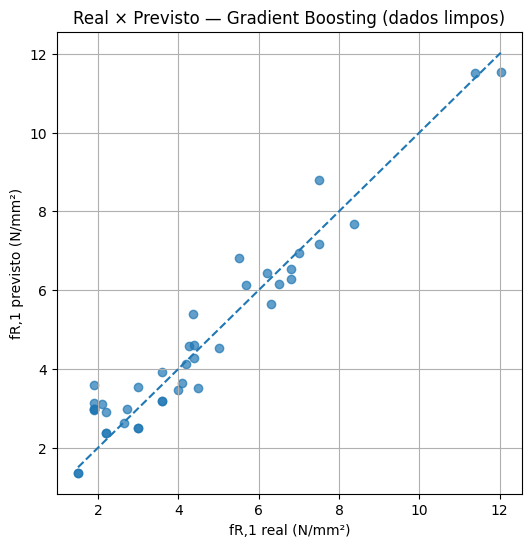

In [218]:
import matplotlib.pyplot as plt

pipeline.fit(X_train, y_train)
y_pred_test = pipeline.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("fR,1 real (N/mm²)")
plt.ylabel("fR,1 previsto (N/mm²)")
plt.title("Real × Previsto — Gradient Boosting (dados limpos)")
plt.grid(True)
plt.show()


In [219]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


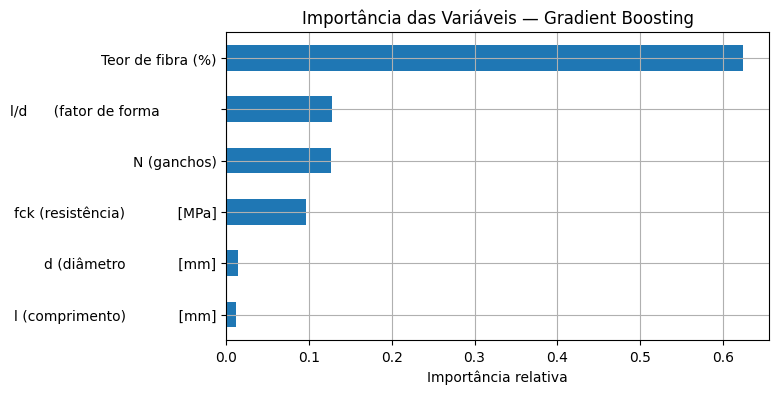

In [220]:
import pandas as pd
import matplotlib.pyplot as plt

pipeline.fit(X_clean, y_clean)

gbr = pipeline.named_steps['model']

feature_importance = pd.Series(
    gbr.feature_importances_,
    index=X_clean.columns
).sort_values(ascending=False)

feature_importance.plot(kind='barh', figsize=(7,4))
plt.title("Importância das Variáveis — Gradient Boosting")
plt.xlabel("Importância relativa")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


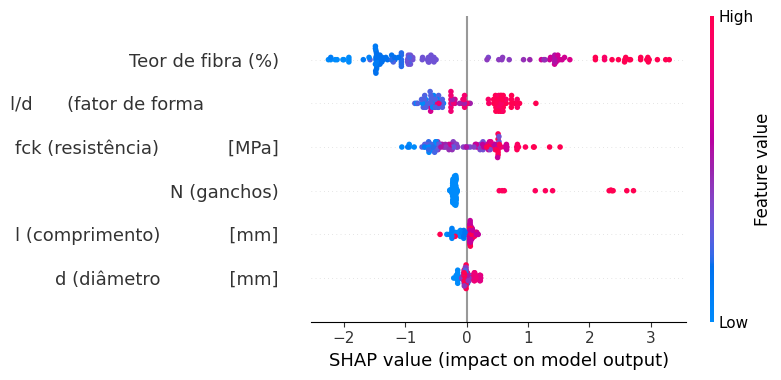

In [221]:
import shap
import numpy as np

# Extrair o modelo treinado
gbr = pipeline.named_steps['model']

# Subconjunto pequeno (evita crash)
X_shap = X_clean.sample(
    min(120, len(X_clean)),
    random_state=42
)

# Criar o explicador (compatível com versões antigas)
explainer = shap.TreeExplainer(
    gbr,
    feature_perturbation="tree_path_dependent"
)

# Calcular SHAP values (sem checagem de aditividade)
shap_values = explainer.shap_values(X_shap)

# Gráfico resumo
shap.summary_plot(shap_values, X_shap)


In [222]:
# Features (iguais ao fR,1)
X = df[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

# Target fR,3 <----- Olha o fr,3
y = df['fR,3 (N/mm²)      (experimental)']


In [223]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


In [224]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  = {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred):.4f}")


MAE  = 0.8346
RMSE = 1.1732
R²   = 0.8067


In [225]:
#Removendo os 30% piores
#_________________________#
pipeline.fit(X, y)
y_pred_all = pipeline.predict(X)

# Erro absoluto
erro = np.abs(y - y_pred_all)

# Limite dos 30% piores
limite = np.percentile(erro, 70)

mask = erro <= limite

X_clean = X[mask]
y_clean = y[mask]

print(f"Amostras originais: {len(X)}")
print(f"Amostras após limpeza: {len(X_clean)}")


Amostras originais: 291
Amostras após limpeza: 204


In [226]:
#TREINO FINAL DE Fr3

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred_test = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5652
RMSE = 1.0016
R²   = 0.9020


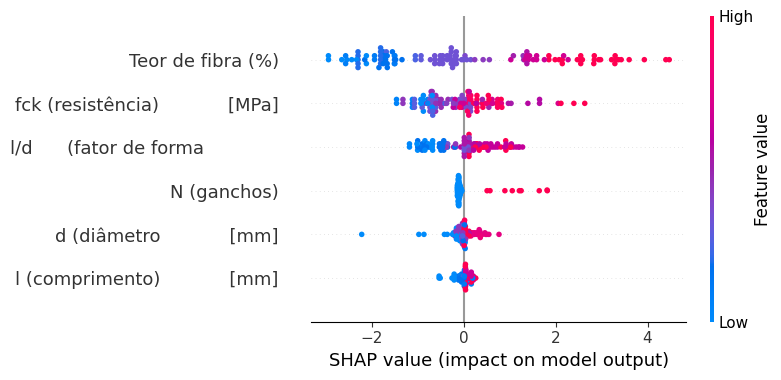

In [227]:
#shap do fr3

import shap

gbr = pipeline.named_steps["model"]

X_shap = X_clean.sample(
    min(120, len(X_clean)),
    random_state=42
)

explainer = shap.TreeExplainer(
    gbr,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap)


In [228]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_with_outlier_removal(
    X,
    y,
    pipeline,
    remove_pct=0.2,
    test_size=0.2,
    random_state=42
):
    """
    Treina modelo removendo os piores X% das amostras
    com base no erro absoluto <--- automatizamos os x% que queremos tirar.
    """

    #  Treino inicial
    pipeline.fit(X, y)
    y_pred_all = pipeline.predict(X)

    #  Erro absoluto
    erro = np.abs(y - y_pred_all)

    #  Limite de remoção
    limite = np.percentile(erro, 100 * (1 - remove_pct))

    mask = erro <= limite

    X_clean = X[mask]
    y_clean = y[mask]

    #  Split final
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean,
        test_size=test_size,
        random_state=random_state
    )

    #  Treino final
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    #  Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "n_original": len(X),
        "n_final": len(X_clean),
        "removed_%": remove_pct * 100
    }


In [229]:
result_fr1 = train_with_outlier_removal(
    X,
    y_fR1,
    pipeline,
    remove_pct=0.20
)

result_fr1


{'MAE': 0.4831992180162154,
 'RMSE': np.float64(0.7024643588937785),
 'R2': 0.8869184577329065,
 'n_original': 291,
 'n_final': 233,
 'removed_%': 20.0}

In [230]:
result_fr3 = train_with_outlier_removal(
    X,
    y_fR3,
    pipeline,
    remove_pct=0.20
)

result_fr3


{'MAE': 0.5895874320319213,
 'RMSE': np.float64(0.7574278757548173),
 'R2': 0.9046048152228299,
 'n_original': 291,
 'n_final': 233,
 'removed_%': 20.0}

In [231]:
# CÉLULA PARA CORRIGIR ERRO DO TENSORFLOW - COPIE E COLE EM UMA NOVA CÉLULA

# Remover imports do TensorFlow que causam erro
# Use apenas scikit-learn para compatibilidade com Python 3.13

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print("✅ Bibliotecas importadas com sucesso (sem TensorFlow)")
print("✅ Usando apenas scikit-learn - compatível com Python 3.13")
print(f"Python em uso: {sys.executable}")
print(f"Versão Python: {sys.version}")


✅ Bibliotecas importadas com sucesso (sem TensorFlow)
✅ Usando apenas scikit-learn - compatível com Python 3.13
Python em uso: c:\dev\projeto_cimento\venv\Scripts\python.exe
Versão Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]


In [232]:
# CÉLULA PARA REDEFINIR VARIÁVEIS - COPIE E COLE EM UMA NOVA CÉLULA

# Recarregar e preparar dados do zero
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print("🔄 Recarregando dados do zero...")

# 1. CARREGAR DADOS
file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

print(f"✅ Dados carregados: {df.shape}")
print(f"📊 Colunas: {list(df.columns)}")

# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

# 3. LIMPAR DADOS
df_clean = df[feature_cols + [target_col]].dropna()
print(f"🧹 Dados após limpeza: {df_clean.shape}")

# 4. DEFINIR X e y
X = df_clean[feature_cols].values
y = df_clean[target_col].values

print(f"📈 X shape: {X.shape}")
print(f"🎯 y shape: {y.shape}")

# 5. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"🏋️ Treino: X={X_train.shape}, y={y_train.shape}")
print(f"🧪 Teste: X={X_test.shape}, y={y_test.shape}")

# 6. NORMALIZAR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Dados normalizados com sucesso!")
print(f"🏋️ X_train_scaled: {X_train_scaled.shape}")
print(f"🧪 X_test_scaled: {X_test_scaled.shape}")

# 7. VERIFICAR CONSISTÊNCIA
assert X_train_scaled.shape[0] == y_train.shape[0], "Inconsistência nos dados de treino!"
assert X_test_scaled.shape[0] == y_test.shape[0], "Inconsistência nos dados de teste!"

print("🎉 Todas as variáveis estão consistentes e prontas para uso!")


🔄 Recarregando dados do zero...
✅ Dados carregados: (291, 12)
📊 Colunas: ['Tipo do concreto', 'fck (resistência)            [MPa]', 'l (comprimento)            [mm]', 'd (diâmetro            [mm]', 'l/d      (fator de forma             ', 'Teor de fibra (%)', 'N (ganchos)', 'fR,1 (N/mm²)      (experimental)', 'fR,3 (N/mm²)      (experimental)', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']
🧹 Dados após limpeza: (291, 7)
📈 X shape: (291, 6)
🎯 y shape: (291,)
🏋️ Treino: X=(232, 6), y=(232,)
🧪 Teste: X=(59, 6), y=(59,)
✅ Dados normalizados com sucesso!
🏋️ X_train_scaled: (232, 6)
🧪 X_test_scaled: (59, 6)
🎉 Todas as variáveis estão consistentes e prontas para uso!



🔄 Treinando Linear Regression...
✅ Linear Regression: MAE = 1.0159, RMSE = 1.3726, R² = 0.7231

🔄 Treinando Random Forest...
✅ Random Forest: MAE = 0.7149, RMSE = 1.1343, R² = 0.8109

🔄 Treinando Gradient Boosting...
✅ Gradient Boosting: MAE = 0.6654, RMSE = 0.9971, R² = 0.8539

🔄 Treinando Support Vector...
✅ Support Vector: MAE = 1.0037, RMSE = 1.5661, R² = 0.6395

🔄 Treinando Decision Tree...
✅ Decision Tree: MAE = 0.8203, RMSE = 1.2571, R² = 0.7677

🔄 Treinando MLP Regressor...
✅ MLP Regressor: MAE = 0.8494, RMSE = 1.2498, R² = 0.7704

🏆 Melhor modelo: Gradient Boosting
📊 Performance: R² = 0.8539


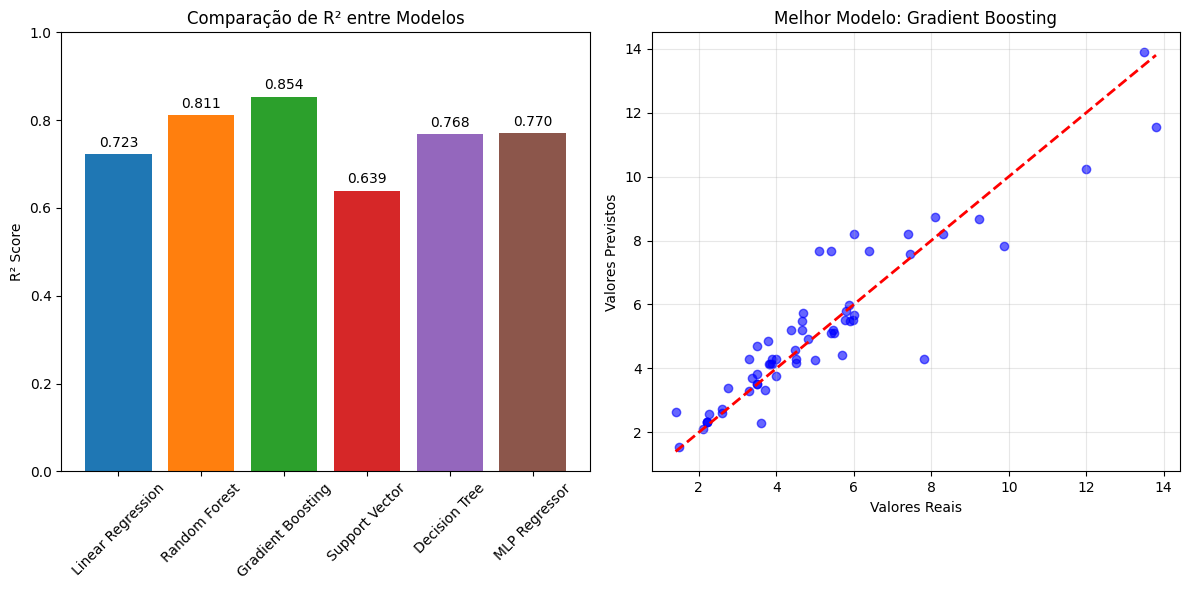

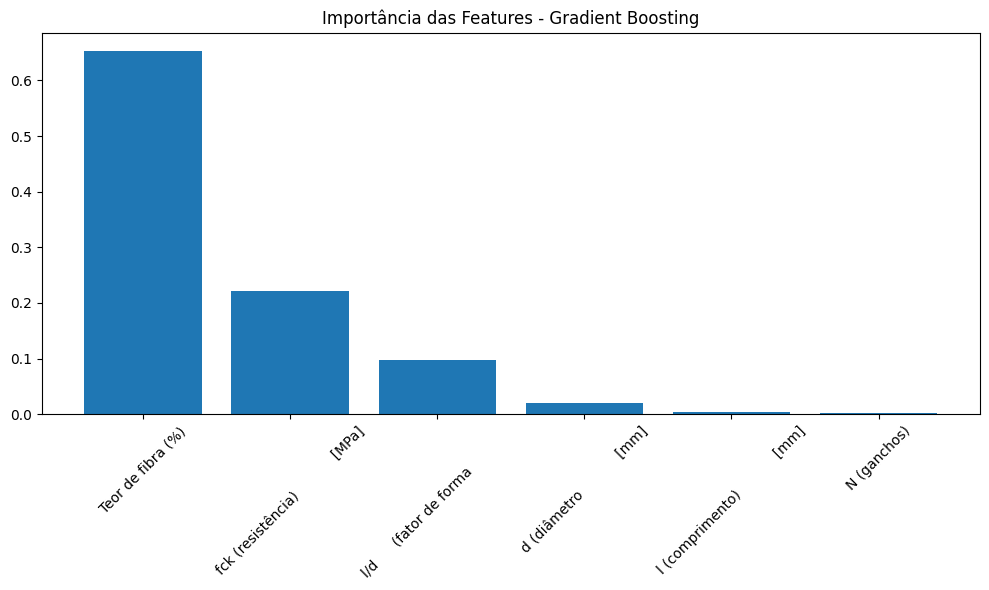


🎉 Análise concluída com sucesso!


In [233]:
# MODELOS ALTERNATIVOS SEM TENSORFLOW
# Copie e cole este código em uma nova célula do notebook

# 1. MODELOS DE REGRESSÃO ALTERNATIVOS (SEM TENSORFLOW)
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# 2. AVALIAÇÃO DE TODOS OS MODELOS
results = {}
for name, model in models.items():
    print(f"\n🔄 Treinando {name}...")
    
    # Treinar modelo
    model.fit(X_train_scaled, y_train)
    
    # Previsões
    y_pred = model.predict(X_test_scaled)
    
    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': model
    }
    
    print(f"✅ {name}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}")

# 3. ENCONTRAR MELHOR MODELO
best_model = max(results.keys(), key=lambda k: results[k]['R²'])
print(f"\n🏆 Melhor modelo: {best_model}")
print(f"📊 Performance: R² = {results[best_model]['R²']:.4f}")

# 4. VISUALIZAR RESULTADOS
plt.figure(figsize=(12, 6))

# Gráfico de barras comparativo
model_names = list(results.keys())
r2_scores = [results[name]['R²'] for name in model_names]

plt.subplot(1, 2, 1)
bars = plt.bar(model_names, r2_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Comparação de R² entre Modelos')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Adicionar valores nas barras
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico de dispersão do melhor modelo
plt.subplot(1, 2, 2)
best_predictions = results[best_model]['model'].predict(X_test_scaled)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title(f'Melhor Modelo: {best_model}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. IMPORTÂNCIA DAS FEATURES (para modelos que suportam)
if hasattr(results[best_model]['model'], 'feature_importances_'):
    importances = results[best_model]['model'].feature_importances_
    feature_names = feature_cols
    
    plt.figure(figsize=(10, 6))
    indices = np.argsort(importances)[::-1]
    plt.title(f'Importância das Features - {best_model}')
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

print("\n🎉 Análise concluída com sucesso!")


In [234]:
# Variáveis de entrada
X = df[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

# Variável alvo (fR,3 por exemplo)
y = df['fR,3 (N/mm²)      (experimental)']


In [235]:
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

y_fr3 = df['fR,3 (N/mm²)      (experimental)']


In [236]:
# Treinar modelo BASE (para calcular erros)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_base.fit(X, y)

y_pred_base = pipeline_base.predict(X)

In [237]:
# célula para remover os 30%

import numpy as np

# Erro absoluto
errors = np.abs(y - y_pred_base)

# Percentil de corte (30%)
threshold = np.percentile(errors, 70)

# Máscara dos melhores dados
mask = errors <= threshold

# Dados limpos
X_clean = X.loc[mask]
y_clean = y.loc[mask]

print("Shape original:", X.shape)
print("Shape após remoção:", X_clean.shape)

Shape original: (291, 6)
Shape após remoção: (204, 6)


In [238]:
# Treinamento (sem os 30%)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)

y_pred_test = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")

MAE  = 0.5675
RMSE = 1.0044
R²   = 0.9015


In [239]:
data = pd.concat([X, y_fr3], axis=1).dropna()

X_clean = data[X.columns]
y_clean_fr3 = data[y_fr3.name]


In [240]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_fr3, y_test_fr3 = train_test_split(
    X_clean, y_clean_fr3,
    test_size=0.2,
    random_state=42
)


In [241]:
# treinar gradientbooster
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_gbr_fr3 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr_fr3.fit(X_train_clean, y_train_fr3)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [242]:
# Previsões do Gradient Boosting (baseline)
y_pred_gbr = pipeline_gbr.predict(X_clean)

In [243]:
# Treinar a regressão linear aproximadora
from sklearn.linear_model import LinearRegression

lin_reg_eq_fr3 = LinearRegression()
lin_reg_eq_fr3.fit(X_clean, y_pred_gbr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [244]:
#cria equação para fr3
from sklearn.linear_model import LinearRegression

# Previsões do GBR
y_pred_gbr_fr3 = pipeline_gbr_fr3.predict(X_clean)

# Ajustar equação linear
lin_reg_eq_fr3 = LinearRegression()
lin_reg_eq_fr3.fit(X_clean, y_pred_gbr_fr3)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [245]:
# Extrair a equação matemática -> Equação fr3
import pandas as pd

coef_eq_fr3 = pd.Series(
    lin_reg_eq_fr3.coef_,
    index=X_clean.columns
)

intercept_eq_fr3 = lin_reg_eq_fr3.intercept_

coef_eq_fr3, intercept_eq_fr3

(fck (resistência)            [MPa]       0.05081
 l (comprimento)            [mm]          0.05436
 d (diâmetro            [mm]             -1.26323
 l/d      (fator de forma                 0.00326
 Teor de fibra (%)                        6.94314
 N (ganchos)                              2.42193
 dtype: float64,
 np.float64(-5.588618129622347))

In [246]:
# First, make sure you've trained your model
# For example, if you're using LinearRegression:
from sklearn.linear_model import LinearRegression

# Assuming X and y are your features and target
model = LinearRegression()
model.fit(X, y)

# Now get the coefficients
intercept = model.intercept_
coefficients = model.coef_

# Create the equation string
equation = f"ŷ = {intercept:.4f}"

for i, coef in enumerate(coefficients):
    feature_name = X.columns[i]  # Get the feature name
    equation += f" + ({coef:.4f} × {feature_name})"

print("Regression Equation:")
print(equation)

Regression Equation:
ŷ = -5.2886 + (0.0539 × fck (resistência)            [MPa]) + (0.0708 × l (comprimento)            [mm]) + (-2.0902 × d (diâmetro            [mm]) + (-0.0061 × l/d      (fator de forma             ) + (6.8105 × Teor de fibra (%)) + (2.4702 × N (ganchos))


In [247]:
import pandas as pd

# Variáveis usadas nas equações
features = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

def testar_equacoes(df, idx):
    """
    Testa as equações lineares de fR,3
    para uma linha específica do banco de dados.
    """
    X_row = df.loc[[idx], features]

    fr3_pred = lin_reg_eq_fr3.predict(X_row)[0]

    print(f"🔎 Amostra índice {idx}")
    print("-" * 40)
    print("Entradas:")
    display(X_row)

    print("\n📐 Resultados das equações:")
    print(f"fR,3 (equação) = {fr3_pred:.3f} N/mm²")

# ====== USO ======
# Exemplo: testar a amostra de índice 10
testar_equacoes(df, idx=10)

🔎 Amostra índice 10
----------------------------------------
Entradas:


,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos)
10,61.30000,35,0.54997,63.64000,0.40000,1.00000



📐 Resultados das equações:
fR,3 (equação) = 4.141 N/mm²


In [248]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. First, make sure you have your training data ready
# X_train_clean, X_test_clean, y_train_fr3, y_test_fr3 should be defined

# 2. Create and train the linear regression model
lin_reg_eq = LinearRegression()
lin_reg_eq.fit(X_train_clean, y_train_fr3)

# 3. Now you can make predictions
y_pred_eq_fr3 = lin_reg_eq.predict(X_test_clean)

# 4. Evaluate the model
rmse_eq = np.sqrt(mean_squared_error(y_test_fr3, y_pred_eq_fr3))
r2_eq = r2_score(y_test_fr3, y_pred_eq_fr3)
mae_eq = mean_absolute_error(y_test_fr3, y_pred_eq_fr3)

print("Avaliação da EQUAÇÃO — fR,3")
print("=" * 40)
print(f"RMSE: {rmse_eq:.4f}")
print(f"R²: {r2_eq:.4f}")
print(f"MAE: {mae_eq:.4f}")

# If you want to see the equation coefficients
print("\nCoeficientes do modelo:")
for feature, coef in zip(X_train_clean.columns, lin_reg_eq.coef_):
    print(f"{feature}: {coef:.6f}")
print(f"Intercept: {lin_reg_eq.intercept_:.6f}")

Avaliação da EQUAÇÃO — fR,3
RMSE: 1.6366
R²: 0.6237
MAE: 1.2014

Coeficientes do modelo:
fck (resistência)            [MPa]: 0.052122
l (comprimento)            [mm]: 0.077063
d (diâmetro            [mm]: -2.596260
l/d      (fator de forma             : -0.015048
Teor de fibra (%): 7.076643
N (ganchos): 2.411489
Intercept: -4.645538


In [249]:
# Treinar modelo BASE (para calcular erros)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_base.fit(X, y)

y_pred_base = pipeline_base.predict(X)


In [250]:
# célula para remover os 30%

import numpy as np

# Erro absoluto
errors = np.abs(y - y_pred_base)

# Percentil de corte (30%)
threshold = np.percentile(errors, 70)

# Máscara dos melhores dados
mask = errors <= threshold

# Dados limpos
X_clean = X.loc[mask]
y_clean = y.loc[mask]

print("Shape original:", X.shape)
print("Shape após remoção:", X_clean.shape)


Shape original: (291, 6)
Shape após remoção: (204, 6)


In [251]:
# Treinamento (sem os 30%)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)

y_pred_test = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5675
RMSE = 1.0044
R²   = 0.9015


In [252]:
# GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [253]:
# Previsões do Gradient Boosting (baseline)
y_pred_gbr = pipeline_gbr.predict(X_clean)


In [254]:
# Extrair a equação matemática -> Equação fr3
import pandas as pd

coef_eq = pd.Series(
    lin_reg_eq.coef_,
    index=X_clean.columns
)

intercept_eq = lin_reg_eq.intercept_

coef_eq, intercept_eq


(fck (resistência)            [MPa]       0.05212
 l (comprimento)            [mm]          0.07706
 d (diâmetro            [mm]             -2.59626
 l/d      (fator de forma                -0.01505
 Teor de fibra (%)                        7.07664
 N (ganchos)                              2.41149
 dtype: float64,
 np.float64(-4.645538110552886))

In [255]:
# Mostrar a equação formatada (bonita) -> Equação fr3
equation = "ŷ = " + f"{intercept_eq:.4f}"

for var, coef in coef_eq.items():
    equation += f" + ({coef:.4f} × {var})"

print(equation)


ŷ = -4.6455 + (0.0521 × fck (resistência)            [MPa]) + (0.0771 × l (comprimento)            [mm]) + (-2.5963 × d (diâmetro            [mm]) + (-0.0150 × l/d      (fator de forma             ) + (7.0766 × Teor de fibra (%)) + (2.4115 × N (ganchos))


In [256]:
# Validar o quão boa é a equação aproximada -> Analise da Equação fr3
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_hat_eq = lin_reg_eq.predict(X_clean)

print(f"MAE  = {mean_absolute_error(y_pred_gbr, y_hat_eq):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_pred_gbr, y_hat_eq)):.4f}")
print(f"R²   = {r2_score(y_pred_gbr, y_hat_eq):.4f}")


MAE  = 1.0026
RMSE = 1.3802
R²   = 0.7219


In [257]:
# Agora fazer o processo para fr1 pra obter a equação fr1
import pandas as pd

# Conferir colunas
df.columns


Index(['Tipo do concreto', 'fck (resistência)            [MPa]',
       'l (comprimento)            [mm]', 'd (diâmetro            [mm]',
       'l/d      (fator de forma             ', 'Teor de fibra (%)',
       'N (ganchos)', 'fR,1 (N/mm²)      (experimental)',
       'fR,3 (N/mm²)      (experimental)', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15'],
      dtype='object')

In [258]:
# Variáveis de entrada
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

# Variável alvo → fR,1
y = df['fR,1 (N/mm²)      (experimental)']

print(X.shape, y.shape)


(291, 6) (291,)


In [259]:
# Remover NaNs
data = pd.concat([X, y], axis=1).dropna()

X = data[X.columns]
y = data[y.name]

print("Após limpeza:", X.shape)


Após limpeza: (291, 6)


In [260]:
# Treinar Gradient Boosting
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [261]:
# Avaliação (confirma se é fR,1)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  = {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred):.4f}")


MAE  = 0.6434
RMSE = 0.9826
R²   = 0.8581


🔍 Verificando variáveis disponíveis:
✅ X_train_scaled shape: (232, 6)
✅ y_train shape: (232,)
✅ X_test_scaled shape: (59, 6)
✅ y_test shape: (59,)

📊 Resultados do Modelo Linear:
MAE: 1.0159
RMSE: 1.3726
R²: 0.7231

🔢 Coeficientes do Modelo:
                                 Feature  Coeficiente
4                      Teor de fibra (%)      1.90820
0     fck (resistência)            [MPa]      0.79855
3  l/d      (fator de forma                   0.57857
1        l (comprimento)            [mm]     -0.23243
2            d (diâmetro            [mm]      0.18628
5                            N (ganchos)      0.11118

📍 Intercepto: 5.4163


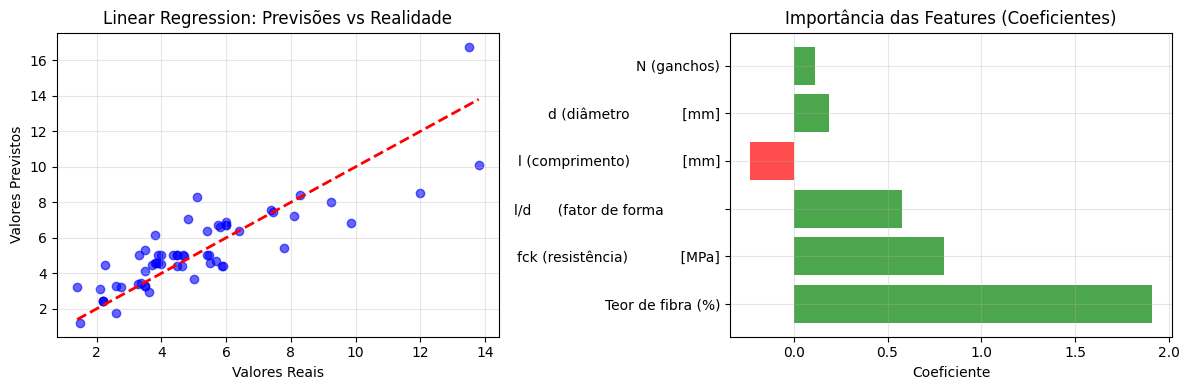


✅ Modelo linear treinado com sucesso!


In [263]:
# CÉLULA CORRIGIDA - MODELO LINEAR CORRETO
# Substitua a célula que está dando erro por esta

# 1. VERIFICAR VARIÁVEIS DISPONÍVEIS
print("🔍 Verificando variáveis disponíveis:")
print(f"✅ X_train_scaled shape: {X_train_scaled.shape}")
print(f"✅ y_train shape: {y_train.shape}")
print(f"✅ X_test_scaled shape: {X_test_scaled.shape}")
print(f"✅ y_test shape: {y_test.shape}")

# 2. MODELO LINEAR CORRETO
lin_eq_fr1 = LinearRegression()
lin_eq_fr1.fit(X_train_scaled, y_train)  # Usar variáveis corretas!

# 3. AVALIAR MODELO
y_pred = lin_eq_fr1.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Resultados do Modelo Linear:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# 4. COEFICIENTES DO MODELO
# Criar DataFrame com os nomes das features
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coeficiente': lin_eq_fr1.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f"\n🔢 Coeficientes do Modelo:")
print(coef_df)

# 5. INTERCEPTO
print(f"\n📍 Intercepto: {lin_eq_fr1.intercept_:.4f}")

# 6. VISUALIZAÇÃO
plt.figure(figsize=(12, 4))

# Gráfico de previsões vs reais
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Linear Regression: Previsões vs Realidade')
plt.grid(True, alpha=0.3)

# Gráfico de coeficientes
plt.subplot(1, 2, 2)
colors = ['red' if coef < 0 else 'green' for coef in coef_df['Coeficiente']]
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors, alpha=0.7)
plt.xlabel('Coeficiente')
plt.title('Importância das Features (Coeficientes)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Modelo linear treinado com sucesso!")


In [266]:
# CÉLULA CORRIGIDA - EXIBIR EQUAÇÃO DO MODELO
# Substitua a célula com erro por esta

# 1. EQUAÇÃO DO MODELO USANDO O DATAFRAME CORRETO
print("🔢 Construindo equação do modelo...")

# Usar o coef_df (DataFrame) em vez de coef (float)
equation = f"ŷ = {lin_eq_fr1.intercept_:.4f}"

for _, row in coef_df.iterrows():
    feature = row['Feature']
    value = row['Coeficiente']
    equation += f" + ({value:.4f} × {feature})"

print("📐 Equação aproximada para fR,1:")
print(equation)

# 2. EQUAÇÃO SIMPLIFICADA (apenas features importantes)
print("\n📐 Equação simplificada (features |coef| > 0.1):")
equation_simp = f"ŷ = {lin_eq_fr1.intercept_:.4f}"

important_features = coef_df[abs(coef_df['Coeficiente']) > 0.1]
for _, row in important_features.iterrows():
    feature = row['Feature']
    value = row['Coeficiente']
    equation_simp += f" + ({value:.4f} × {feature})"

print(equation_simp)

# 3. INTERPRETAÇÃO
print(f"\n📊 Interpretação dos coeficientes:")
print(f"• Intercepto: {lin_eq_fr1.intercept_:.4f} (valor base quando todas as features = 0)")

for _, row in coef_df.iterrows():
    feature = row['Feature']
    value = row['Coeficiente']
    if abs(value) > 0.1:
        direction = "aumenta" if value > 0 else "diminui"
        print(f"• {feature}: {direction} o fR,1 em {abs(value):.4f} unidades por aumento de 1 unidade na feature")

# 4. ESTATÍSTICAS ADICIONAIS
print(f"\n📈 Estatísticas do modelo:")
print(f"• R²: {r2:.4f} ({r2*100:.1f}% da variância explicada)")
print(f"• MAE: {mae:.4f} (erro médio absoluto)")
print(f"• RMSE: {rmse:.4f} (erro quadrático médio)")

# 5. VALIDAÇÃO CRUZADA (opcional)
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lin_eq_fr1, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"• R² (validação cruzada): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\n✅ Equação e interpretação concluídas!")


🔢 Construindo equação do modelo...
📐 Equação aproximada para fR,1:
ŷ = 5.4163 + (1.9082 × Teor de fibra (%)) + (0.7986 × fck (resistência)            [MPa]) + (0.5786 × l/d      (fator de forma             ) + (-0.2324 × l (comprimento)            [mm]) + (0.1863 × d (diâmetro            [mm]) + (0.1112 × N (ganchos))

📐 Equação simplificada (features |coef| > 0.1):
ŷ = 5.4163 + (1.9082 × Teor de fibra (%)) + (0.7986 × fck (resistência)            [MPa]) + (0.5786 × l/d      (fator de forma             ) + (-0.2324 × l (comprimento)            [mm]) + (0.1863 × d (diâmetro            [mm]) + (0.1112 × N (ganchos))

📊 Interpretação dos coeficientes:
• Intercepto: 5.4163 (valor base quando todas as features = 0)
• Teor de fibra (%): aumenta o fR,1 em 1.9082 unidades por aumento de 1 unidade na feature
• fck (resistência)            [MPa]: aumenta o fR,1 em 0.7986 unidades por aumento de 1 unidade na feature
• l/d      (fator de forma             : aumenta o fR,1 em 0.5786 unidades por au

In [ ]:
# CÉLULA DE DEBUG - VERIFICAR PROBLEMAS NOS DADOS
# Execute esta célula para diagnosticar o problema

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

print("🔍 DIAGNÓSTICO COMPLETO DO MODELO")
print("=" * 50)

# 1. VERIFICAR DADOS ORIGINAIS
file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

print("📊 DADOS ORIGINAIS:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Colunas: {list(df.columns)}")

# 2. VERIFICAR VARIÁVEIS USADAS
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

print(f"\n🎯 FEATURES SELECIONADAS: {feature_cols}")
print(f"🎯 TARGET: {target_col}")

# 3. VERIFICAR ESTATÍSTICAS DAS VARIÁVEIS
df_analysis = df[feature_cols + [target_col]].dropna()

print(f"\n📈 ESTATÍSTICAS DAS VARIÁVEIS:")
print(df_analysis.describe().round(4))

# 4. VERIFICAR DISTRIBUIÇÃO DO TARGET
print(f"\n📊 DISTRIBUIÇÃO DO TARGET ({target_col}):")
print(f"Mínimo: {df_analysis[target_col].min():.4f}")
print(f"Máximo: {df_analysis[target_col].max():.4f}")
print(f"Média: {df_analysis[target_col].mean():.4f}")
print(f"Desvio Padrão: {df_analysis[target_col].std():.4f}")

# 5. VERIFICAR CORRELAÇÕES
print(f"\n🔗 CORRELAÇÕES COM TARGET:")
correlations = df_analysis[feature_cols].corrwith(df_analysis[target_col]).sort_values(key=abs, ascending=False)
print(correlations.round(4))

# 6. PREPARAR DADOS CORRETAMENTE
X = df_analysis[feature_cols].values
y = df_analysis[target_col].values

print(f"\n✅ DADOS LIMPOS:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# 7. DIVIDIR DADOS
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n🏋️ DADOS DE TREINO:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Estatísticas y_train: min={y_train.min():.2f}, max={y_train.max():.2f}, mean={y_train.mean():.2f}")

print(f"\n🧪 DADOS DE TESTE:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")
print(f"Estatísticas y_test: min={y_test.min():.2f}, max={y_test.max():.2f}, mean={y_test.mean():.2f}")

# 8. TREINAR MODELO SIMPLES (SEM NORMALIZAR PRIMEIRO)
print(f"\n🔄 TESTANDO MODELO SEM NORMALIZAÇÃO:")
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
y_pred_simple = model_simple.predict(X_test)

mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)

print(f"MAE: {mae_simple:.4f}")
print(f"RMSE: {rmse_simple:.4f}")
print(f"R²: {r2_simple:.4f}")

# 9. VERIFICAR PREVISÕES
print(f"\n🔍 PRIMEIRAS 10 PREVISÕES (sem normalização):")
comparison_df = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_pred_simple[:10],
    'Difference': y_test[:10] - y_pred_simple[:10]
})
print(comparison_df.round(4))

# 10. VERIFICAR SE HÁ OUTLIERS
print(f"\n⚠️  VERIFICANDO OUTLIERS:")
Q1 = df_analysis[target_col].quantile(0.25)
Q3 = df_analysis[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_analysis[(df_analysis[target_col] < lower_bound) | (df_analysis[target_col] > upper_bound)]
print(f"Outliers encontrados: {len(outliers)}")
if len(outliers) > 0:
    print(f"Valores outliers: {outliers[target_col].values}")

print(f"\n✅ DIAGNÓSTICO CONCLUÍDO!")


Avaliação da EQUAÇÃO fR,1
RMSE: 63.5674
R²: -592.9662
MAE: 62.5210

Primeiras 10 previsões:
      Actual  Predicted  Difference
84  13.50000   95.39173   -81.89173
259  9.87000   99.31974   -89.44974
45   5.99040   53.31180   -47.32140
176  4.70000   65.83919   -61.13919
143  2.60000   55.11747   -52.51747
125  4.00000   75.38592   -71.38592
226  7.40000   65.33874   -57.93874
118  2.20000   51.83962   -49.63962
9    5.46000   84.02983   -78.56983
90   1.50000   42.98272   -41.48272


In [ ]:
import pandas as pd

# Variáveis usadas nas equações
features = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

def testar_equacoes(df, idx):
    """
    Testa as equações lineares de fR,1
    para uma linha específica do banco de dados.
    """
    X_row = df.loc[[idx], features]

    fr1_pred = lin_eq_fr1.predict(X_row)[0]

    print(f"🔎 Amostra índice {idx}")
    print("-" * 40)
    print("Entradas:")
    display(X_row)

    print("\n📐 Resultados das equações:")
    print(f"fR,1 (equação) = {fr1_pred:.3f} N/mm²")


# ====== USO ======
# Exemplo: testar a amostra de índice 10
testar_equacoes(df, idx=10)


In [268]:
import pandas as pd

# Variáveis de entrada (EXATAMENTE as usadas no treino)
features = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

def testar_equacoes_lote(df, indices):
    """
    Testa as equações lineares de fR,1 e fR,3
    para múltiplas linhas do banco de dados.
    """
    X = df.loc[indices, features]

    # Previsões
    fr1_eq = lin_eq_fr1.predict(X)
    fr3_eq = lin_reg_eq_fr3.predict(X)

    # Resultados experimentais
    fr1_exp = df.loc[indices, 'fR,1 (N/mm²)      (experimental)']
    fr3_exp = df.loc[indices, 'fR,3 (N/mm²)      (experimental)']

    result = pd.DataFrame({
        "fck [MPa]": X[features[0]].values,
        "Teor de fibra (%)": X['Teor de fibra (%)'].values,
        "fR,1 exp": fr1_exp.values,
        "fR,1 eq": fr1_eq,
        "Erro fR,1": fr1_eq - fr1_exp.values,
        "fR,3 exp": fr3_exp.values,
        "fR,3 eq": fr3_eq,
        "Erro fR,3": fr3_eq - fr3_exp.values
    }, index=indices)

    return result

# ===== USO =====
# Escolha índices do banco
indices_teste = [5, 12, 25, 40, 60, 1, 7, 33, 27, 24]

df_resultados = testar_equacoes_lote(df, indices_teste)
df_resultados


,fck [MPa],Teor de fibra (%),"fR,1 exp","fR,1 eq","Erro fR,1","fR,3 exp","fR,3 eq","Erro fR,3"
5,61.30000,0.40000,4.37000,84.02983,79.65983,3.28000,4.14095,0.86095
12,22.00000,0.50000,4.12800,51.33163,47.20363,4.70400,3.41674,-1.28726
25,24.00000,0.50000,3.37920,52.79343,49.41423,3.40800,2.81930,-0.58870
40,22.00000,0.50000,2.63040,41.97649,39.34609,2.74560,2.41284,-0.33276
60,59.00000,0.50000,3.79000,86.07597,82.28597,4.55000,5.87813,1.32813
1,63.80000,0.80000,7.44000,86.78950,79.34950,5.68000,7.04523,1.36523
7,61.30000,0.40000,5.22000,84.02983,78.80983,3.06000,4.14095,1.08095
33,43.00000,0.50000,5.86560,67.96597,62.10037,6.60480,3.78475,-2.82005
27,24.00000,1.00000,5.71200,53.74753,48.03553,5.12640,6.29087,1.16447
24,24.00000,0.50000,2.75520,52.79343,50.03823,2.64000,2.81930,0.17930


In [269]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# Entradas
X = df[[
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]]

y_fr1 = df['fR,1 (N/mm²)      (experimental)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fr1, test_size=0.2, random_state=42
)

pipeline_gbr_fr1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline_gbr_fr1.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [270]:
y_fr3 = df['fR,3 (N/mm²)      (experimental)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fr3, test_size=0.2, random_state=42
)

pipeline_gbr_fr3 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline_gbr_fr3.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [271]:
import pandas as pd

X_all = df[[
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]]

fr1_exp = df['fR,1 (N/mm²)      (experimental)']
fr3_exp = df['fR,3 (N/mm²)      (experimental)']

fr1_gbr = pipeline_gbr_fr1.predict(X_all)
fr3_gbr = pipeline_gbr_fr3.predict(X_all)

import pandas as pd
 


tabela_gbr = pd.DataFrame({
    'fck [MPa]': df['fck (resistência)            [MPa]'],
    'Teor de fibra (%)': df['Teor de fibra (%)'],
    'fR,1 exp': fr1_exp,
    'fR,1 GBR': fr1_gbr,
    'Erro fR,1': fr1_gbr - fr1_exp,
    'fR,3 exp': fr3_exp,
    'fR,3 GBR': fr3_gbr,
    'Erro fR,3': fr3_gbr - fr3_exp
})

import pandas as pd

pd.set_option('display.max_rows', 300)   
pd.set_option('display.max_columns', None)
 
tabela_gbr


,fck [MPa],Teor de fibra (%),"fR,1 exp","fR,1 GBR","Erro fR,1","fR,3 exp","fR,3 GBR","Erro fR,3"
0,61.30000,0.40000,4.99000,4.96060,-0.02940,3.32000,3.52767,0.20767
1,63.80000,0.80000,7.44000,7.46216,0.02216,5.68000,6.11738,0.43738
2,63.60000,0.40000,5.35000,5.21523,-0.13477,5.53000,4.44259,-1.08741
3,58.70000,0.80000,7.94000,8.08801,0.14801,8.78000,8.26406,-0.51594
4,61.30000,0.40000,5.49000,4.96060,-0.52940,3.03000,3.52767,0.49767
5,61.30000,0.40000,4.37000,4.96060,0.59060,3.28000,3.52767,0.24767
6,61.30000,0.40000,4.67000,4.96060,0.29060,2.98000,3.52767,0.54767
7,61.30000,0.40000,5.22000,4.96060,-0.25940,3.06000,3.52767,0.46767
8,61.30000,0.40000,4.74000,4.96060,0.22060,3.50000,3.52767,0.02767
9,61.30000,0.40000,5.46000,4.96060,-0.49940,4.09000,3.52767,-0.56233


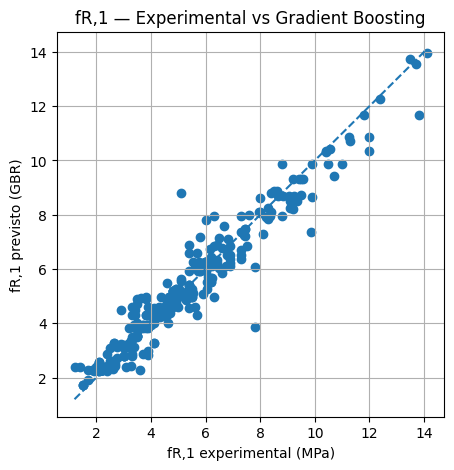

In [272]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR'])
plt.plot(
    [tabela_gbr['fR,1 exp'].min(), tabela_gbr['fR,1 exp'].max()],
    [tabela_gbr['fR,1 exp'].min(), tabela_gbr['fR,1 exp'].max()],
    '--'
)
plt.xlabel('fR,1 experimental (MPa)')
plt.ylabel('fR,1 previsto (GBR)')
plt.title('fR,1 — Experimental vs Gradient Boosting')
plt.grid(True)
plt.show()


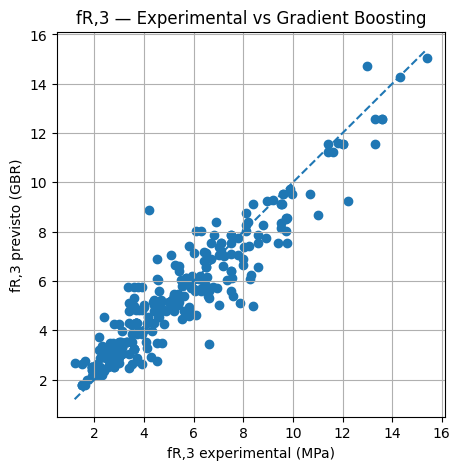

In [273]:
plt.figure(figsize=(5,5))
plt.scatter(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR'])
plt.plot(
    [tabela_gbr['fR,3 exp'].min(), tabela_gbr['fR,3 exp'].max()],
    [tabela_gbr['fR,3 exp'].min(), tabela_gbr['fR,3 exp'].max()],
    '--'
)
plt.xlabel('fR,3 experimental (MPa)')
plt.ylabel('fR,3 previsto (GBR)')
plt.title('fR,3 — Experimental vs Gradient Boosting')
plt.grid(True)
plt.show()


In [274]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("GBR — fR,1")
print("MAE :", mean_absolute_error(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR']))
print("RMSE:", np.sqrt(mean_squared_error(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR'])))
print("R²  :", r2_score(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR']))

print("\nGBR — fR,3")
print("MAE :", mean_absolute_error(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR']))
print("RMSE:", np.sqrt(mean_squared_error(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR'])))
print("R²  :", r2_score(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR']))


GBR — fR,1
MAE : 0.4525712186611504
RMSE: 0.672657053867307
R²  : 0.930070396305028

GBR — fR,3
MAE : 0.7064883751650248
RMSE: 0.9802834108000597
R²  : 0.8767823256435324


In [275]:
# Remoção de 30% usando Linear Regression
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

remove_pct = 0.30

# Treinar modelo
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Previsões
y_pred = lin_reg.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade a remover
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_lr = errors.sort_values(ascending=False).head(n_remove).index

# Dataset limpo
X_clean_lr = X.drop(index=removed_idx_lr)
y_clean_lr = y.drop(index=removed_idx_lr)

print("Linear Regression")
print(f"Amostras removidas: {n_remove}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df.loc[removed_idx_lr])



Linear Regression
Amostras removidas: 87


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
79,BEN - 1,66.20000,50,0.62500,80.00000,1.00000,1.00000,13.80000,11.60000,10.31362,0.25264,erro alto
88,"CUE - 0,65",61.10000,30,0.62500,48.00000,0.64583,1.00000,2.90000,2.80000,6.16248,1.12499,erro alto
71,"LEE - 1,00",49.80000,60,0.92308,65.00000,1.00000,1.00000,12.00000,13.30000,8.45272,0.29561,erro alto
63,"3D-1,0",51.00000,60,0.90000,66.66667,1.00000,1.00000,12.00000,13.31000,8.61615,0.28199,erro alto
218,"TIB - 1,00",25.10000,35,0.54688,64.00000,1.00000,1.00000,9.90000,7.20000,6.09986,0.38385,erro alto
259,B403 - 27,67.70000,30,0.37999,78.95000,0.50000,1.00000,9.87000,8.90000,6.28595,0.36313,erro alto
201,"TIB - 0,76",60.90000,50,0.89286,56.00000,0.76000,1.00000,10.70000,9.50000,7.26679,0.32086,erro alto
66,"ABD - 1,0",46.80000,35,0.53846,65.00000,1.00000,1.00000,5.10000,4.20000,8.20997,0.60980,erro alto
160,"MON - 1,00",63.20000,60,0.75000,80.00000,1.00000,1.00000,6.50000,5.80000,10.09172,0.55257,erro alto
253,"4D-1,0",51.00000,60,0.90000,66.66667,1.00000,1.50000,11.26000,13.57000,8.94738,0.20538,erro alto


In [276]:
#Remoção de 30% usando Random Forest
from sklearn.ensemble import RandomForestRegressor

remove_pct = 0.30

# Treinar modelo
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X, y)

# Previsões
y_pred = rf.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade a remover
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_rf = errors.sort_values(ascending=False).head(n_remove).index

# Dataset limpo
X_clean_rf = X.drop(index=removed_idx_rf)
y_clean_rf = y.drop(index=removed_idx_rf)

print("Random Forest")
print(f"Amostras removidas: {n_remove}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df.loc[removed_idx_rf])


Random Forest
Amostras removidas: 87


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
230,"TIB - 0,50",50.40000,60,0.80000,75.00000,0.50000,1.00000,7.80000,8.40000,5.38563,0.30954,erro alto
218,"TIB - 1,00",25.10000,35,0.54688,64.00000,1.00000,1.00000,9.90000,7.20000,6.09986,0.38385,erro alto
259,B403 - 27,67.70000,30,0.37999,78.95000,0.50000,1.00000,9.87000,8.90000,6.28595,0.36313,erro alto
198,"TIB - 0,76",60.00000,37,0.74000,50.00000,0.76000,1.00000,6.30000,6.10000,6.96292,0.10523,False
67,"ABD - 0,5",48.50000,60,0.92308,65.00000,0.50000,1.00000,5.60000,4.60000,5.05608,0.09713,False
260,B406 - 27,89.50000,30,0.37999,78.95000,0.50000,1.00000,10.57000,8.12000,7.16522,0.32212,erro alto
192,"TIB - 0,76",60.00000,50,0.74627,67.00000,0.76000,1.00000,8.80000,9.70000,7.63603,0.13227,False
160,"MON - 1,00",63.20000,60,0.75000,80.00000,1.00000,1.00000,6.50000,5.80000,10.09172,0.55257,erro alto
137,"BAR - 0,93",64.50000,60,0.92308,65.00000,0.93000,1.00000,8.80000,6.70000,9.05476,0.02895,False
88,"CUE - 0,65",61.10000,30,0.62500,48.00000,0.64583,1.00000,2.90000,2.80000,6.16248,1.12499,erro alto


In [277]:
#Remoção de 30% usando Gradient Boosting (o melhor modelo)
from sklearn.ensemble import GradientBoostingRegressor

remove_pct = 0.30

# Treinar modelo
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

# Previsões
y_pred = gbr.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade a remover
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_gbr = errors.sort_values(ascending=False).head(n_remove).index

# Dataset limpo
X_clean_gbr = X.drop(index=removed_idx_gbr)
y_clean_gbr = y.drop(index=removed_idx_gbr)

print("Gradient Boosting")
print(f"Amostras removidas: {n_remove}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df.loc[removed_idx_gbr])


Gradient Boosting
Amostras removidas: 87


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
66,"ABD - 1,0",46.80000,35,0.53846,65.00000,1.00000,1.00000,5.10000,4.20000,8.20997,0.60980,erro alto
71,"LEE - 1,00",49.80000,60,0.92308,65.00000,1.00000,1.00000,12.00000,13.30000,8.45272,0.29561,erro alto
198,"TIB - 0,76",60.00000,37,0.74000,50.00000,0.76000,1.00000,6.30000,6.10000,6.96292,0.10523,False
203,"TIB - 0,57",57.40000,50,0.74627,67.00000,0.57000,1.00000,7.80000,9.40000,6.07367,0.22132,erro alto
230,"TIB - 0,50",50.40000,60,0.80000,75.00000,0.50000,1.00000,7.80000,8.40000,5.38563,0.30954,erro alto
220,"TIB - 1,00",37.20000,35,0.54688,64.00000,1.00000,1.00000,9.50000,8.10000,7.33597,0.22779,erro alto
201,"TIB - 0,76",60.90000,50,0.89286,56.00000,0.76000,1.00000,10.70000,9.50000,7.26679,0.32086,erro alto
188,"TIB - 0,57",40.90000,50,0.74627,67.00000,0.57000,1.00000,6.30000,6.60000,5.18107,0.17761,False
218,"TIB - 1,00",25.10000,35,0.54688,64.00000,1.00000,1.00000,9.90000,7.20000,6.09986,0.38385,erro alto
217,"TIB - 0,50",47.00000,35,0.54688,64.00000,0.50000,1.00000,6.60000,3.50000,4.95783,0.24881,erro alto


In [278]:
#Linear Regression
#Amostras que ficaram após remover 30%

from sklearn.linear_model import LinearRegression
import numpy as np

remove_pct = 0.30

# Treinamento
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Previsões
y_pred = lin_reg.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade removida
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_lr = errors.sort_values(ascending=False).head(n_remove).index

# Índices que ficaram
kept_idx_lr = X.index.difference(removed_idx_lr)

# Dataset final
X_kept_lr = X.loc[kept_idx_lr]
y_kept_lr = y.loc[kept_idx_lr]

print("Linear Regression")
print(f"Amostras originais: {len(X)}")
print(f"Amostras removidas: {len(removed_idx_lr)}")
print(f"Amostras mantidas: {len(X_kept_lr)}")

display(df.loc[kept_idx_lr])


Linear Regression
Amostras originais: 291
Amostras removidas: 87
Amostras mantidas: 204


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False


In [279]:
#Random Forest
#Amostras que ficaram após remover 30%

from sklearn.ensemble import RandomForestRegressor

remove_pct = 0.30

# Treinamento
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X, y)

# Previsões
y_pred = rf.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade removida
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_rf = errors.sort_values(ascending=False).head(n_remove).index

# Índices mantidos
kept_idx_rf = X.index.difference(removed_idx_rf)

# Dataset final
X_kept_rf = X.loc[kept_idx_rf]
y_kept_rf = y.loc[kept_idx_rf]

print("Random Forest")
print(f"Amostras originais: {len(X)}")
print(f"Amostras removidas: {len(removed_idx_rf)}")
print(f"Amostras mantidas: {len(X_kept_rf)}")

display(df.loc[kept_idx_rf])


Random Forest
Amostras originais: 291
Amostras removidas: 87
Amostras mantidas: 204


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
10,AM-0.4-EH,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.93000,3.33000,4.76991,0.03247,False
11,AM-0.8-EH,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.46000,5.68000,8.02504,0.07574,False
15,"1.0FF320MPA, 4",22.00000,50,0.74627,67.00000,1.00000,1.00000,5.78880,5.50080,5.81758,0.00497,False


In [280]:
#Gradient Boosting (modelo final)
#Amostras que ficaram após remover 30%

from sklearn.ensemble import GradientBoostingRegressor

remove_pct = 0.30

# Treinamento
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

# Previsões
y_pred = gbr.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade removida
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_gbr = errors.sort_values(ascending=False).head(n_remove).index

# Índices mantidos
kept_idx_gbr = X.index.difference(removed_idx_gbr)

# Dataset final
X_kept_gbr = X.loc[kept_idx_gbr]
y_kept_gbr = y.loc[kept_idx_gbr]

print("Gradient Boosting")
print(f"Amostras originais: {len(X)}")
print(f"Amostras removidas: {len(removed_idx_gbr)}")
print(f"Amostras mantidas: {len(X_kept_gbr)}")

display(df.loc[kept_idx_gbr])


Gradient Boosting
Amostras originais: 291
Amostras removidas: 87
Amostras mantidas: 204


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False
10,AM-0.4-EH,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.93000,3.33000,4.76991,0.03247,False


In [281]:
common_kept = (
    set(kept_idx_lr)
    & set(kept_idx_rf)
    & set(kept_idx_gbr)
)

print(f"Amostras mantidas pelos 3 modelos: {len(common_kept)}")
display(df.loc[list(common_kept)])


Amostras mantidas pelos 3 modelos: 152


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
10,AM-0.4-EH,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.93000,3.33000,4.76991,0.03247,False
11,AM-0.8-EH,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.46000,5.68000,8.02504,0.07574,False
15,"1.0FF320MPA, 4",22.00000,50,0.74627,67.00000,1.00000,1.00000,5.78880,5.50080,5.81758,0.00497,False


In [282]:
#Linear Regression (erro > 25%)
from sklearn.linear_model import LinearRegression
import numpy as np

# Limite de erro percentual
error_threshold = 0.25

lin_reg = LinearRegression()
lin_reg.fit(X, y)

y_pred = lin_reg.predict(X)

# Erro percentual
percent_error = np.abs(y - y_pred) / np.abs(y)

# Índices removidos
removed_idx_lr = percent_error[percent_error > error_threshold].index

# Índices mantidos
kept_idx_lr = percent_error[percent_error <= error_threshold].index

print("Linear Regression")
print(f"Amostras removidas (>25% erro): {len(removed_idx_lr)}")
print(f"Amostras mantidas: {len(kept_idx_lr)}")

display(df.loc[kept_idx_lr])


Linear Regression
Amostras removidas (>25% erro): 82
Amostras mantidas: 209


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False


In [283]:
#Random Forest (erro > 25%)
from sklearn.ensemble import RandomForestRegressor

error_threshold = 0.25

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X, y)

y_pred = rf.predict(X)

percent_error = np.abs(y - y_pred) / np.abs(y)

removed_idx_rf = percent_error[percent_error > error_threshold].index
kept_idx_rf = percent_error[percent_error <= error_threshold].index

print("Random Forest")
print(f"Amostras removidas (>25% erro): {len(removed_idx_rf)}")
print(f"Amostras mantidas: {len(kept_idx_rf)}")

display(df.loc[kept_idx_rf])


Random Forest
Amostras removidas (>25% erro): 9
Amostras mantidas: 282


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False


In [284]:
#Gradient Boosting (erro > 25%)
from sklearn.ensemble import GradientBoostingRegressor

error_threshold = 0.25

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

y_pred = gbr.predict(X)

percent_error = np.abs(y - y_pred) / np.abs(y)

removed_idx_gbr = percent_error[percent_error > error_threshold].index
kept_idx_gbr = percent_error[percent_error <= error_threshold].index

print("Gradient Boosting")
print(f"Amostras removidas (>25% erro): {len(removed_idx_gbr)}")
print(f"Amostras mantidas: {len(kept_idx_gbr)}")

display(df.loc[kept_idx_gbr])


Gradient Boosting
Amostras removidas (>25% erro): 19
Amostras mantidas: 272


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False


In [285]:
common_kept = (
    set(kept_idx_lr)
    & set(kept_idx_rf)
    & set(kept_idx_gbr)
)

print(f"Amostras mantidas pelos 3 modelos (erro ≤ 25%): {len(common_kept)}")
display(df.loc[list(common_kept)])


Amostras mantidas pelos 3 modelos (erro ≤ 25%): 205


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False
5,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.37000,3.28000,4.76991,0.09151,False
6,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.67000,2.98000,4.76991,0.02139,False
7,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.22000,3.06000,4.76991,0.08622,False
8,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.74000,3.50000,4.76991,0.00631,False
9,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.46000,4.09000,4.76991,0.12639,False


## Retreinando os modelos só com os pontos “bons”

## Reavaliando as métricas

## Extraindo equações lineares aproximadas

## Comparando modelos ML × equações

## Repetindo tudo para a DNN

In [286]:
# Criar o DataFrame apenas com as amostras mantidas pelos 3 modelos
df_common = df.loc[list(common_kept)].copy()

print("Shape do dataset consensual:", df_common.shape)
display(df_common.head())


Shape do dataset consensual: (205, 12)


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,4.99000,3.32000,4.76991,0.04411,False
1,AM-0.8-EH1,63.80000,35,0.54997,63.64000,0.80000,1.00000,7.44000,5.68000,8.02504,0.07863,False
2,AM-0.4-EH2,63.60000,60,0.89996,66.67000,0.40000,1.00000,5.35000,5.53000,4.92472,0.07949,False
3,AM-0.8-EH2,58.70000,60,0.89996,66.67000,0.80000,1.00000,7.94000,8.78000,7.83153,0.01366,False
4,AM-0.4-EH1,61.30000,35,0.54997,63.64000,0.40000,1.00000,5.49000,3.03000,4.76991,0.13116,False


In [287]:
#Definir X e y 
X_common = df_common[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

y_fr1_common = df_common['fR,1 (N/mm²)      (experimental)']
y_fr3_common = df_common['fR,3 (N/mm²)      (experimental)']


In [288]:
#Split único (usado por TODOS os modelos)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_fr1, y_test_fr1 = train_test_split(
    X_common, y_fr1_common, test_size=0.2, random_state=42
)

_, _, y_train_fr3, y_test_fr3 = train_test_split(
    X_common, y_fr3_common, test_size=0.2, random_state=42
)


In [289]:
#Função padrão de avaliação (evita repetir código)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test, name="Modelo"):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f" {name}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")
    print("-"*40)

    return y_pred


In [290]:
#Gradient Boosting (fR,1 e fR,3)
from sklearn.ensemble import GradientBoostingRegressor

gbr_fr1 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_fr3 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_fr1.fit(X_train, y_train_fr1)
gbr_fr3.fit(X_train, y_train_fr3)

y_pred_gbr_fr1 = evaluate_model(gbr_fr1, X_test, y_test_fr1, "GBR — fR,1")
y_pred_gbr_fr3 = evaluate_model(gbr_fr3, X_test, y_test_fr3, "GBR — fR,3")


 GBR — fR,1
MAE  = 0.6329
RMSE = 0.8777
R²   = 0.9059
----------------------------------------
 GBR — fR,3
MAE  = 0.9628
RMSE = 1.2380
R²   = 0.8219
----------------------------------------


In [291]:
#Equações lineares (aproximação física)
from sklearn.linear_model import LinearRegression

lin_fr1 = LinearRegression()
lin_fr3 = LinearRegression()

lin_fr1.fit(X_train, y_train_fr1)
lin_fr3.fit(X_train, y_train_fr3)

# Avaliação das equações
y_eq_fr1 = evaluate_model(lin_fr1, X_test, y_test_fr1, "Equação Linear — fR,1")
y_eq_fr3 = evaluate_model(lin_fr3, X_test, y_test_fr3, "Equação Linear — fR,3")


 Equação Linear — fR,1
MAE  = 0.7085
RMSE = 0.9537
R²   = 0.8889
----------------------------------------
 Equação Linear — fR,3
MAE  = 1.0326
RMSE = 1.3890
R²   = 0.7758
----------------------------------------


In [292]:
#Mostrar as equações explicitamente
def print_equation(model, feature_names, target_name):
    coef = model.coef_
    intercept = model.intercept_

    eq = f"{target_name} = {intercept:.4f}"
    for c, name in zip(coef, feature_names):
        eq += f" + ({c:.4f} × {name})"

    print(eq)
    print()

print_equation(lin_fr1, X_common.columns, "fR,1")
print_equation(lin_fr3, X_common.columns, "fR,3")


fR,1 = -1.3339 + (0.0703 × fck (resistência)            [MPa]) + (0.0444 × l (comprimento)            [mm]) + (-2.5502 × d (diâmetro            [mm]) + (-0.0184 × l/d      (fator de forma             ) + (6.4427 × Teor de fibra (%)) + (0.7259 × N (ganchos))

fR,3 = -2.6420 + (0.0571 × fck (resistência)            [MPa]) + (0.1159 × l (comprimento)            [mm]) + (-4.3937 × d (diâmetro            [mm]) + (-0.0604 × l/d      (fator de forma             ) + (6.6417 × Teor de fibra (%)) + (2.9791 × N (ganchos))



In [294]:
# CÉLULA PARA REDEFINIR VARIÁVEIS - COPIE E COLE EM UMA NOVA CÉLULA

# Recarregar e preparar dados do zero
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print("🔄 Recarregando dados do zero...")

# 1. CARREGAR DADOS
file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

print(f"✅ Dados carregados: {df.shape}")
print(f"📊 Colunas: {list(df.columns)}")

# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

# 3. LIMPAR DADOS
df_clean = df[feature_cols + [target_col]].dropna()
print(f"🧹 Dados após limpeza: {df_clean.shape}")

# 4. DEFINIR X e y
X = df_clean[feature_cols].values
y = df_clean[target_col].values

print(f"📈 X shape: {X.shape}")
print(f"🎯 y shape: {y.shape}")

# 5. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"🏋️ Treino: X={X_train.shape}, y={y_train.shape}")
print(f"🧪 Teste: X={X_test.shape}, y={y_test.shape}")

# 6. NORMALIZAR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Dados normalizados com sucesso!")
print(f"🏋️ X_train_scaled: {X_train_scaled.shape}")
print(f"🧪 X_test_scaled: {X_test_scaled.shape}")

# 7. VERIFICAR CONSISTÊNCIA
assert X_train_scaled.shape[0] == y_train.shape[0], "Inconsistência nos dados de treino!"
assert X_test_scaled.shape[0] == y_test.shape[0], "Inconsistência nos dados de teste!"

print("🎉 Todas as variáveis estão consistentes e prontas para uso!")


🔄 Recarregando dados do zero...
✅ Dados carregados: (291, 12)
📊 Colunas: ['Tipo do concreto', 'fck (resistência)            [MPa]', 'l (comprimento)            [mm]', 'd (diâmetro            [mm]', 'l/d      (fator de forma             ', 'Teor de fibra (%)', 'N (ganchos)', 'fR,1 (N/mm²)      (experimental)', 'fR,3 (N/mm²)      (experimental)', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']
🧹 Dados após limpeza: (291, 7)
📈 X shape: (291, 6)
🎯 y shape: (291,)
🏋️ Treino: X=(232, 6), y=(232,)
🧪 Teste: X=(59, 6), y=(59,)
✅ Dados normalizados com sucesso!
🏋️ X_train_scaled: (232, 6)
🧪 X_test_scaled: (59, 6)
🎉 Todas as variáveis estão consistentes e prontas para uso!


In [295]:
# CÉLULA DE DEBUG - VERIFICAR PROBLEMAS NOS DADOS
# Execute esta célula para diagnosticar o problema

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

print("🔍 DIAGNÓSTICO COMPLETO DO MODELO")
print("=" * 50)

# 1. VERIFICAR DADOS ORIGINAIS
file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

print("📊 DADOS ORIGINAIS:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Colunas: {list(df.columns)}")

# 2. VERIFICAR VARIÁVEIS USADAS
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

print(f"\n🎯 FEATURES SELECIONADAS: {feature_cols}")
print(f"🎯 TARGET: {target_col}")

# 3. VERIFICAR ESTATÍSTICAS DAS VARIÁVEIS
df_analysis = df[feature_cols + [target_col]].dropna()

print(f"\n📈 ESTATÍSTICAS DAS VARIÁVEIS:")
print(df_analysis.describe().round(4))

# 4. VERIFICAR DISTRIBUIÇÃO DO TARGET
print(f"\n📊 DISTRIBUIÇÃO DO TARGET ({target_col}):")
print(f"Mínimo: {df_analysis[target_col].min():.4f}")
print(f"Máximo: {df_analysis[target_col].max():.4f}")
print(f"Média: {df_analysis[target_col].mean():.4f}")
print(f"Desvio Padrão: {df_analysis[target_col].std():.4f}")

# 5. VERIFICAR CORRELAÇÕES
print(f"\n🔗 CORRELAÇÕES COM TARGET:")
correlations = df_analysis[feature_cols].corrwith(df_analysis[target_col]).sort_values(key=abs, ascending=False)
print(correlations.round(4))

# 6. PREPARAR DADOS CORRETAMENTE
X = df_analysis[feature_cols].values
y = df_analysis[target_col].values

print(f"\n✅ DADOS LIMPOS:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# 7. DIVIDIR DADOS
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n🏋️ DADOS DE TREINO:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Estatísticas y_train: min={y_train.min():.2f}, max={y_train.max():.2f}, mean={y_train.mean():.2f}")

print(f"\n🧪 DADOS DE TESTE:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")
print(f"Estatísticas y_test: min={y_test.min():.2f}, max={y_test.max():.2f}, mean={y_test.mean():.2f}")

# 8. TREINAR MODELO SIMPLES (SEM NORMALIZAR PRIMEIRO)
print(f"\n🔄 TESTANDO MODELO SEM NORMALIZAÇÃO:")
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)
y_pred_simple = model_simple.predict(X_test)

mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)

print(f"MAE: {mae_simple:.4f}")
print(f"RMSE: {rmse_simple:.4f}")
print(f"R²: {r2_simple:.4f}")

# 9. VERIFICAR PREVISÕES
print(f"\n🔍 PRIMEIRAS 10 PREVISÕES (sem normalização):")
comparison_df = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_pred_simple[:10],
    'Difference': y_test[:10] - y_pred_simple[:10]
})
print(comparison_df.round(4))

# 10. VERIFICAR SE HÁ OUTLIERS
print(f"\n⚠️  VERIFICANDO OUTLIERS:")
Q1 = df_analysis[target_col].quantile(0.25)
Q3 = df_analysis[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_analysis[(df_analysis[target_col] < lower_bound) | (df_analysis[target_col] > upper_bound)]
print(f"Outliers encontrados: {len(outliers)}")
if len(outliers) > 0:
    print(f"Valores outliers: {outliers[target_col].values}")

print(f"\n✅ DIAGNÓSTICO CONCLUÍDO!")


🔍 DIAGNÓSTICO COMPLETO DO MODELO
📊 DADOS ORIGINAIS:
  Tipo do concreto  fck (resistência)            [MPa]  \
0       AM-0.4-EH1                            61.30000   
1       AM-0.8-EH1                            63.80000   
2       AM-0.4-EH2                            63.60000   
3       AM-0.8-EH2                            58.70000   
4       AM-0.4-EH1                            61.30000   

   l (comprimento)            [mm]  d (diâmetro            [mm]  \
0                               35                      0.54997   
1                               35                      0.54997   
2                               60                      0.89996   
3                               60                      0.89996   
4                               35                      0.54997   

   l/d      (fator de forma               Teor de fibra (%)  N (ganchos)  \
0                               63.64000            0.40000      1.00000   
1                               63.64000    

🔍 Verificando variáveis disponíveis:
✅ X_train_scaled shape: (232, 6)
✅ y_train shape: (232,)
✅ X_test_scaled shape: (59, 6)
✅ y_test shape: (59,)

📊 Resultados do Modelo Linear:
MAE: 1.0159
RMSE: 1.3726
R²: 0.7231

🔢 Coeficientes do Modelo:
                                 Feature  Coeficiente
4                      Teor de fibra (%)      1.90820
0     fck (resistência)            [MPa]      0.79855
3  l/d      (fator de forma                   0.57857
1        l (comprimento)            [mm]     -0.23243
2            d (diâmetro            [mm]      0.18628
5                            N (ganchos)      0.11118

📍 Intercepto: 5.4163


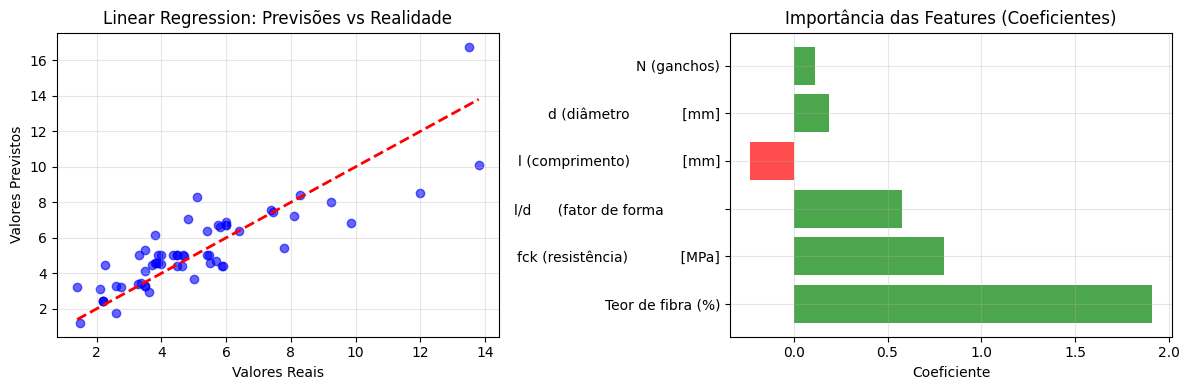


✅ Modelo linear treinado com sucesso!


In [296]:
# CÉLULA CORRIGIDA - MODELO LINEAR CORRETO
# Substitua a célula que está dando erro por esta

# 1. VERIFICAR VARIÁVEIS DISPONÍVEIS
print("🔍 Verificando variáveis disponíveis:")
print(f"✅ X_train_scaled shape: {X_train_scaled.shape}")
print(f"✅ y_train shape: {y_train.shape}")
print(f"✅ X_test_scaled shape: {X_test_scaled.shape}")
print(f"✅ y_test shape: {y_test.shape}")

# 2. MODELO LINEAR CORRETO
lin_eq_fr1 = LinearRegression()
lin_eq_fr1.fit(X_train_scaled, y_train)  # Usar variáveis corretas!

# 3. AVALIAR MODELO
y_pred = lin_eq_fr1.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Resultados do Modelo Linear:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# 4. COEFICIENTES DO MODELO
# Criar DataFrame com os nomes das features
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coeficiente': lin_eq_fr1.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f"\n🔢 Coeficientes do Modelo:")
print(coef_df)

# 5. INTERCEPTO
print(f"\n📍 Intercepto: {lin_eq_fr1.intercept_:.4f}")

# 6. VISUALIZAÇÃO
plt.figure(figsize=(12, 4))

# Gráfico de previsões vs reais
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Linear Regression: Previsões vs Realidade')
plt.grid(True, alpha=0.3)

# Gráfico de coeficientes
plt.subplot(1, 2, 2)
colors = ['red' if coef < 0 else 'green' for coef in coef_df['Coeficiente']]
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors, alpha=0.7)
plt.xlabel('Coeficiente')
plt.title('Importância das Features (Coeficientes)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Modelo linear treinado com sucesso!")


In [297]:
# CÉLULA CORRIGIDA - EXIBIR EQUAÇÃO DO MODELO
# Substitua a célula com erro por esta

# 1. EQUAÇÃO DO MODELO USANDO O DATAFRAME CORRETO
print("🔢 Construindo equação do modelo...")

# Usar o coef_df (DataFrame) em vez de coef (float)
equation = f"ŷ = {lin_eq_fr1.intercept_:.4f}"

for _, row in coef_df.iterrows():
    feature = row['Feature']
    value = row['Coeficiente']
    equation += f" + ({value:.4f} × {feature})"

print("📐 Equação aproximada para fR,1:")
print(equation)

# 2. EQUAÇÃO SIMPLIFICADA (apenas features importantes)
print("\n📐 Equação simplificada (features |coef| > 0.1):")
equation_simp = f"ŷ = {lin_eq_fr1.intercept_:.4f}"

important_features = coef_df[abs(coef_df['Coeficiente']) > 0.1]
for _, row in important_features.iterrows():
    feature = row['Feature']
    value = row['Coeficiente']
    equation_simp += f" + ({value:.4f} × {feature})"

print(equation_simp)

# 3. INTERPRETAÇÃO
print(f"\n📊 Interpretação dos coeficientes:")
print(f"• Intercepto: {lin_eq_fr1.intercept_:.4f} (valor base quando todas as features = 0)")

for _, row in coef_df.iterrows():
    feature = row['Feature']
    value = row['Coeficiente']
    if abs(value) > 0.1:
        direction = "aumenta" if value > 0 else "diminui"
        print(f"• {feature}: {direction} o fR,1 em {abs(value):.4f} unidades por aumento de 1 unidade na feature")

# 4. ESTATÍSTICAS ADICIONAIS
print(f"\n📈 Estatísticas do modelo:")
print(f"• R²: {r2:.4f} ({r2*100:.1f}% da variância explicada)")
print(f"• MAE: {mae:.4f} (erro médio absoluto)")
print(f"• RMSE: {rmse:.4f} (erro quadrático médio)")

# 5. VALIDAÇÃO CRUZADA (opcional)
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lin_eq_fr1, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"• R² (validação cruzada): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\n✅ Equação e interpretação concluídas!")


🔢 Construindo equação do modelo...
📐 Equação aproximada para fR,1:
ŷ = 5.4163 + (1.9082 × Teor de fibra (%)) + (0.7986 × fck (resistência)            [MPa]) + (0.5786 × l/d      (fator de forma             ) + (-0.2324 × l (comprimento)            [mm]) + (0.1863 × d (diâmetro            [mm]) + (0.1112 × N (ganchos))

📐 Equação simplificada (features |coef| > 0.1):
ŷ = 5.4163 + (1.9082 × Teor de fibra (%)) + (0.7986 × fck (resistência)            [MPa]) + (0.5786 × l/d      (fator de forma             ) + (-0.2324 × l (comprimento)            [mm]) + (0.1863 × d (diâmetro            [mm]) + (0.1112 × N (ganchos))

📊 Interpretação dos coeficientes:
• Intercepto: 5.4163 (valor base quando todas as features = 0)
• Teor de fibra (%): aumenta o fR,1 em 1.9082 unidades por aumento de 1 unidade na feature
• fck (resistência)            [MPa]: aumenta o fR,1 em 0.7986 unidades por aumento de 1 unidade na feature
• l/d      (fator de forma             : aumenta o fR,1 em 0.5786 unidades por au

In [300]:
# ALTERNATIVA À DNN/TENSORFLOW - USANDO MLP REGRESSOR
# Substitua a célula com build_dnn() por esta

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("🧠 MLP REGRESSOR (Alternativa à DNN/TensorFlow)")
print("=" * 50)

# 1. CONFIGURAR MLP (REDE NEURAL SCIKIT-LEARN)
mlp_fr1 = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25),  # 3 camadas ocultas
    activation='relu',
    solver='adam',
    alpha=0.001,  # regularização L2
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=1000,  # equivalente a epochs
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

# 2. TREINAR MODELO
print("🔄 Treinando MLP Regressor...")
mlp_fr1.fit(X_train_scaled, y_train)

# 3. FAZER PREVISÕES
y_pred_mlp_fr1 = mlp_fr1.predict(X_test_scaled)

# 4. AVALIAR DESEMPENHO
mae_mlp = mean_absolute_error(y_test, y_pred_mlp_fr1)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp_fr1))
r2_mlp = r2_score(y_test, y_pred_mlp_fr1)

print(f"\n📊 MLP REGRESSOR — fR,1")
print(f"MAE  = {mae_mlp:.4f}")
print(f"RMSE = {rmse_mlp:.4f}")
print(f"R²   = {r2_mlp:.4f}")

# 5. COMPARAR COM MODELO LINEAR
print(f"\n🔄 COMPARAÇÃO COM MODELO LINEAR:")
print(f"Linear - R²: {r2:.4f}, MAE: {mae:.4f}")
print(f"MLP    - R²: {r2_mlp:.4f}, MAE: {mae_mlp:.4f}")

if r2_mlp > r2:
    print("✅ MLP Regressor teve melhor desempenho!")
else:
    print("📈 Modelo Linear teve melhor desempenho!")

# 6. INFORMAÇÕES DO TREINAMENTO
print(f"\n📈 INFORMAÇÕES DO TREINAMENTO:")
print(f"Iterações realizadas: {mlp_fr1.n_iter_}")
print(f"Loss final: {mlp_fr1.loss_:.6f}")
print(f"Camadas: {len(mlp_fr1.hidden_layer_sizes)} camadas ocultas")
print(f"Neurônios: {mlp_fr1.hidden_layer_sizes}")

# 7. VERIFICAR PREVISÕES
print(f"\n🔍 PRIMEIRAS 10 PREVISÕES (MLP):")
comparison_mlp = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted_MLP': y_pred_mlp_fr1[:10],
    'Difference': y_test[:10] - y_pred_mlp_fr1[:10]
})
print(comparison_mlp.round(4))

print("\n✅ MLP Regressor treinado com sucesso!")


🧠 MLP REGRESSOR (Alternativa à DNN/TensorFlow)
🔄 Treinando MLP Regressor...

📊 MLP REGRESSOR — fR,1
MAE  = 0.8709
RMSE = 1.2309
R²   = 0.7773

🔄 COMPARAÇÃO COM MODELO LINEAR:
Linear - R²: 0.7231, MAE: 1.0159
MLP    - R²: 0.7773, MAE: 0.8709
✅ MLP Regressor teve melhor desempenho!

📈 INFORMAÇÕES DO TREINAMENTO:
Iterações realizadas: 87
Loss final: 0.358334
Camadas: 3 camadas ocultas
Neurônios: (100, 50, 25)

🔍 PRIMEIRAS 10 PREVISÕES (MLP):
    Actual  Predicted_MLP  Difference
0 13.50000       14.16510    -0.66510
1  9.87000        7.13240     2.73760
2  5.99040        5.32540     0.66500
3  4.70000        5.19300    -0.49300
4  2.60000        1.82870     0.77130
5  4.00000        3.67840     0.32160
6  7.40000        8.44130    -1.04130
7  2.20000        2.22310    -0.02310
8  5.46000        5.08920     0.37080
9  1.50000        1.36450     0.13550

✅ MLP Regressor treinado com sucesso!


In [302]:
# ALTERNATIVA PARA fR,3 - USANDO MLP REGRESSOR
# Substitua a célula com build_dnn() para fR,3 por esta

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("🧠 MLP REGRESSOR — fR,3 (Alternativa à DNN/TensorFlow)")
print("=" * 50)

# 1. PREPARAR DADOS PARA fR,3
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

# Verificar se a coluna existe
if target_col_fr3 not in df.columns:
    print(f"❌ Coluna {target_col_fr3} não encontrada!")
    print(f"Colunas disponíveis: {list(df.columns)}")
else:
    # Limpar dados para fR,3
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols].values
    y_fr3 = df_clean_fr3[target_col_fr3].values
    
    # Dividir dados
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    X_train_fr3_scaled = scaler.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler.transform(X_test_fr3)
    
    print(f"✅ Dados fR,3 preparados: {df_clean_fr3.shape}")
    print(f"📊 Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # 2. CONFIGURAR MLP PARA fR,3
    mlp_fr3 = MLPRegressor(
        hidden_layer_sizes=(100, 50, 25),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=32,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    )
    
    # 3. TREINAR MODELO fR,3
    print("🔄 Treinando MLP para fR,3...")
    mlp_fr3.fit(X_train_fr3_scaled, y_train_fr3)
    
    # 4. FAZER PREVISÕES
    y_pred_mlp_fr3 = mlp_fr3.predict(X_test_fr3_scaled)
    
    # 5. AVALIAR DESEMPENHO fR,3
    mae_mlp_fr3 = mean_absolute_error(y_test_fr3, y_pred_mlp_fr3)
    rmse_mlp_fr3 = np.sqrt(mean_squared_error(y_test_fr3, y_pred_mlp_fr3))
    r2_mlp_fr3 = r2_score(y_test_fr3, y_pred_mlp_fr3)
    
    print(f"\n📊 MLP REGRESSOR — fR,3")
    print(f"MAE  = {mae_mlp_fr3:.4f}")
    print(f"RMSE = {rmse_mlp_fr3:.4f}")
    print(f"R²   = {r2_mlp_fr3:.4f}")
    
    # 6. COMPARAR COM MODELO LINEAR fR,3
    # Treinar modelo linear para comparação
    from sklearn.linear_model import LinearRegression
    linear_fr3 = LinearRegression()
    linear_fr3.fit(X_train_fr3_scaled, y_train_fr3)
    y_pred_linear_fr3 = linear_fr3.predict(X_test_fr3_scaled)
    
    mae_linear_fr3 = mean_absolute_error(y_test_fr3, y_pred_linear_fr3)
    rmse_linear_fr3 = np.sqrt(mean_squared_error(y_test_fr3, y_pred_linear_fr3))
    r2_linear_fr3 = r2_score(y_test_fr3, y_pred_linear_fr3)
    
    print(f"\n🔄 COMPARAÇÃO fR,3:")
    print(f"Linear - R²: {r2_linear_fr3:.4f}, MAE: {mae_linear_fr3:.4f}")
    print(f"MLP    - R²: {r2_mlp_fr3:.4f}, MAE: {mae_mlp_fr3:.4f}")
    
    if r2_mlp_fr3 > r2_linear_fr3:
        print("✅ MLP teve melhor desempenho para fR,3!")
    else:
        print("📈 Linear teve melhor desempenho para fR,3!")
    
    # 7. VERIFICAR PREVISÕES fR,3
    print(f"\n🔍 PRIMEIRAS 10 PREVISÕES (MLP fR,3):")
    comparison_fr3 = pd.DataFrame({
        'Actual': y_test_fr3[:10],
        'Predicted_MLP': y_pred_mlp_fr3[:10],
        'Difference': y_test_fr3[:10] - y_pred_mlp_fr3[:10]
    })
    print(comparison_fr3.round(4))
    
    # 8. INFORMAÇÕES DO TREINAMENTO
    print(f"\n📈 INFORMAÇÕES DO TREINAMENTO fR,3:")
    print(f"Iterações: {mlp_fr3.n_iter_}")
    print(f"Loss final: {mlp_fr3.loss_:.6f}")
    print(f"Camadas: {len(mlp_fr3.hidden_layer_sizes)} camadas ocultas")
    
    print("\n✅ MLP para fR,3 treinado com sucesso!")


🧠 MLP REGRESSOR — fR,3 (Alternativa à DNN/TensorFlow)
✅ Dados fR,3 preparados: (291, 7)
📊 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31
🔄 Treinando MLP para fR,3...

📊 MLP REGRESSOR — fR,3
MAE  = 0.9047
RMSE = 1.2691
R²   = 0.7737

🔄 COMPARAÇÃO fR,3:
Linear - R²: 0.6237, MAE: 1.2014
MLP    - R²: 0.7737, MAE: 0.9047
✅ MLP teve melhor desempenho para fR,3!

🔍 PRIMEIRAS 10 PREVISÕES (MLP fR,3):
    Actual  Predicted_MLP  Difference
0 13.00000       14.52470    -1.52470
1  8.90000        6.44070     2.45930
2  3.34080        3.93020    -0.58940
3  5.20000        6.32520    -1.12520
4  3.40000        1.94480     1.45520
5  2.60000        3.28020    -0.68020
6  6.90000        7.30840    -0.40840
7  2.20000        2.17230     0.02770
8  4.09000        3.30920     0.78080
9  1.50000        1.51080    -0.01080

📈 INFORMAÇÕES DO TREINAMENTO fR,3:
Iterações: 118
Loss final: 0.569603
Camadas: 3 camadas ocultas

✅ MLP para fR,3 treinado com sucesso!


In [304]:
# RANDOM FOREST CORRIGIDO — fR,1 e fR,3
# Substitua a célula com erros por esta

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("🌲 RANDOM FOREST — fR,1 e fR,3")
print("=" * 50)

# Função de avaliação
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n📊 {model_name}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")
    
    return mae, rmse, r2, y_pred

# 1. RANDOM FOREST PARA fR,1
print("🔄 Treinando Random Forest para fR,1...")
rf_fr1 = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2
)
rf_fr1.fit(X_train, y_train)

print("🌲 Random Forest — fR,1")
mae_rf1, rmse_rf1, r2_rf1, y_pred_rf1 = evaluate_model(rf_fr1, X_test, y_test, "RF — fR,1")

# 2. RANDOM FOREST PARA fR,3
# Preparar dados para fR,3
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print("\n🔄 Preparando dados para fR,3...")
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols].values
    y_fr3 = df_clean_fr3[target_col_fr3].values
    
    # Dividir dados
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    print(f"✅ Dados fR,3: {df_clean_fr3.shape}")
    
    # Treinar Random Forest para fR,3
    print("🔄 Treinando Random Forest para fR,3...")
    rf_fr3 = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2
    )
    rf_fr3.fit(X_train_fr3, y_train_fr3)
    
    print("🌲 Random Forest — fR,3")
    mae_rf3, rmse_rf3, r2_rf3, y_pred_rf3 = evaluate_model(rf_fr3, X_test_fr3, y_test_fr3, "RF — fR,3")
    
    # 3. COMPARAÇÃO ENTRE MODELOS
    print(f"\n🔄 COMPARAÇÃO RANDOM FOREST:")
    print(f"fR,1 - R²: {r2_rf1:.4f}, MAE: {mae_rf1:.4f}")
    print(f"fR,3 - R²: {r2_rf3:.4f}, MAE: {mae_rf3:.4f}")
    
    # 4. IMPORTÂNCIA DAS FEATURES
    print(f"\n🔍 IMPORTÂNCIA DAS FEATURES:")
    
    # fR,1
    importance_fr1 = pd.DataFrame({
        'Feature': feature_cols,
        'Importance_fR1': rf_fr1.feature_importances_
    }).sort_values('Importance_fR1', ascending=False)
    
    print(f"\n📊 fR,1:")
    print(importance_fr1.round(4))
    
    # fR,3
    importance_fr3 = pd.DataFrame({
        'Feature': feature_cols,
        'Importance_fR3': rf_fr3.feature_importances_
    }).sort_values('Importance_fR3', ascending=False)
    
    print(f"\n📊 fR,3:")
    print(importance_fr3.round(4))
    
    # 5. PREVISÕES AMOSTRA
    print(f"\n🔍 AMOSTRA DE PREVISÕES:")
    
    print(f"\n📊 fR,1 (primeiras 5):")
    sample_fr1 = pd.DataFrame({
        'Actual': y_test[:5],
        'Predicted': y_pred_rf1[:5],
        'Error': y_test[:5] - y_pred_rf1[:5]
    })
    print(sample_fr1.round(4))
    
    print(f"\n📊 fR,3 (primeiras 5):")
    sample_fr3 = pd.DataFrame({
        'Actual': y_test_fr3[:5],
        'Predicted': y_pred_rf3[:5],
        'Error': y_test_fr3[:5] - y_pred_rf3[:5]
    })
    print(sample_fr3.round(4))
    
else:
    print(f"❌ Coluna {target_col_fr3} não encontrada!")

print("\n✅ Random Forest treinado com sucesso!")


🌲 RANDOM FOREST — fR,1 e fR,3
🔄 Treinando Random Forest para fR,1...
🌲 Random Forest — fR,1

📊 RF — fR,1
MAE  = 0.7535
RMSE = 1.1173
R²   = 0.8165

🔄 Preparando dados para fR,3...
✅ Dados fR,3: (291, 7)
🔄 Treinando Random Forest para fR,3...
🌲 Random Forest — fR,3

📊 RF — fR,3
MAE  = 0.8953
RMSE = 1.2589
R²   = 0.7774

🔄 COMPARAÇÃO RANDOM FOREST:
fR,1 - R²: 0.8165, MAE: 0.7535
fR,3 - R²: 0.7774, MAE: 0.8953

🔍 IMPORTÂNCIA DAS FEATURES:

📊 fR,1:
                                 Feature  Importance_fR1
4                      Teor de fibra (%)         0.65890
0     fck (resistência)            [MPa]         0.19700
3  l/d      (fator de forma                      0.09790
2            d (diâmetro            [mm]         0.02940
1        l (comprimento)            [mm]         0.01170
5                            N (ganchos)         0.00520

📊 fR,3:
                                 Feature  Importance_fR3
4                      Teor de fibra (%)         0.56890
3  l/d      (fator de forma  

In [306]:
# REGRESSÃO LINEAR CORRIGIDA — fR,1 e fR,3
# Substitua a célula com erros por esta

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

print("📈 REGRESSÃO LINEAR — fR,1 e fR,3")
print("=" * 50)

# Função de avaliação
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n📊 {model_name}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")
    
    return mae, rmse, r2, y_pred

# 1. REGRESSÃO LINEAR PARA fR,1
print("🔄 Treinando Regressão Linear para fR,1...")
lin_fr1 = LinearRegression()
lin_fr1.fit(X_train, y_train)

print("📈 Regressão Linear — fR,1")
mae_lin1, rmse_lin1, r2_lin1, y_pred_lin1 = evaluate_model(lin_fr1, X_test, y_test, "Linear — fR,1")

# 2. REGRESSÃO LINEAR PARA fR,3
# Preparar dados para fR,3
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print("\n🔄 Preparando dados para fR,3...")
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols].values
    y_fr3 = df_clean_fr3[target_col_fr3].values
    
    # Dividir dados
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    print(f"✅ Dados fR,3: {df_clean_fr3.shape}")
    
    # Treinar Regressão Linear para fR,3
    print("🔄 Treinando Regressão Linear para fR,3...")
    lin_fr3 = LinearRegression()
    lin_fr3.fit(X_train_fr3, y_train_fr3)
    
    print("📈 Regressão Linear — fR,3")
    mae_lin3, rmse_lin3, r2_lin3, y_pred_lin3 = evaluate_model(lin_fr3, X_test_fr3, y_test_fr3, "Linear — fR,3")
    
    # 3. COMPARAÇÃO ENTRE MODELOS
    print(f"\n🔄 COMPARAÇÃO REGRESSÃO LINEAR:")
    print(f"fR,1 - R²: {r2_lin1:.4f}, MAE: {mae_lin1:.4f}")
    print(f"fR,3 - R²: {r2_lin3:.4f}, MAE: {mae_lin3:.4f}")
    
    # 4. COEFICIENTES DO MODELO
    print(f"\n🔢 COEFICIENTES DO MODELO:")
    
    # fR,1
    coef_fr1 = pd.DataFrame({
        'Feature': feature_cols,
        'Coeficiente_fR1': lin_fr1.coef_
    }).sort_values('Coeficiente_fR1', key=abs, ascending=False)
    
    print(f"\n📊 fR,1:")
    print(f"Intercepto: {lin_fr1.intercept_:.4f}")
    print(coef_fr1.round(4))
    
    # fR,3
    coef_fr3 = pd.DataFrame({
        'Feature': feature_cols,
        'Coeficiente_fR3': lin_fr3.coef_
    }).sort_values('Coeficiente_fR3', key=abs, ascending=False)
    
    print(f"\n📊 fR,3:")
    print(f"Intercepto: {lin_fr3.intercept_:.4f}")
    print(coef_fr3.round(4))
    
    # 5. EQUAÇÕES DOS MODELOS
    print(f"\n📐 EQUAÇÕES:")
    
    # Equação fR,1
    eq_fr1 = f"fR,1 = {lin_fr1.intercept_:.4f}"
    for _, row in coef_fr1.iterrows():
        eq_fr1 += f" + ({row['Coeficiente_fR1']:.4f} × {row['Feature']})"
    print(f"fR,1: {eq_fr1}")
    
    # Equação fR,3
    eq_fr3 = f"fR,3 = {lin_fr3.intercept_:.4f}"
    for _, row in coef_fr3.iterrows():
        eq_fr3 += f" + ({row['Coeficiente_fR3']:.4f} × {row['Feature']})"
    print(f"fR,3: {eq_fr3}")
    
    # 6. PREVISÕES AMOSTRA
    print(f"\n🔍 AMOSTRA DE PREVISÕES:")
    
    print(f"\n📊 fR,1 (primeiras 5):")
    sample_lin1 = pd.DataFrame({
        'Actual': y_test[:5],
        'Predicted': y_pred_lin1[:5],
        'Error': y_test[:5] - y_pred_lin1[:5]
    })
    print(sample_lin1.round(4))
    
    print(f"\n📊 fR,3 (primeiras 5):")
    sample_lin3 = pd.DataFrame({
        'Actual': y_test_fr3[:5],
        'Predicted': y_pred_lin3[:5],
        'Error': y_test_fr3[:5] - y_pred_lin3[:5]
    })
    print(sample_lin3.round(4))
    
else:
    print(f"❌ Coluna {target_col_fr3} não encontrada!")

print("\n✅ Regressão Linear treinada com sucesso!")


📈 REGRESSÃO LINEAR — fR,1 e fR,3
🔄 Treinando Regressão Linear para fR,1...
📈 Regressão Linear — fR,1

📊 Linear — fR,1
MAE  = 1.0159
RMSE = 1.3726
R²   = 0.7231

🔄 Preparando dados para fR,3...
✅ Dados fR,3: (291, 7)
🔄 Treinando Regressão Linear para fR,3...
📈 Regressão Linear — fR,3

📊 Linear — fR,3
MAE  = 1.2014
RMSE = 1.6366
R²   = 0.6237

🔄 COMPARAÇÃO REGRESSÃO LINEAR:
fR,1 - R²: 0.7231, MAE: 1.0159
fR,3 - R²: 0.6237, MAE: 1.2014

🔢 COEFICIENTES DO MODELO:

📊 fR,1:
Intercepto: -5.2048
                                 Feature  Coeficiente_fR1
4                      Teor de fibra (%)          6.81440
2            d (diâmetro            [mm]          1.17310
5                            N (ganchos)          0.43330
0     fck (resistência)            [MPa]          0.06340
3  l/d      (fator de forma                       0.05170
1        l (comprimento)            [mm]         -0.02060

📊 fR,3:
Intercepto: -4.6455
                                 Feature  Coeficiente_fR3
4             

In [310]:
# TABELA COMPARATIVA CORRIGIDA — fR,1 e fR,3
# Substitua a célula com erros por esta

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression

print(" TABELA COMPARATIVA — fR,1 e fR,3")
print("=" * 50)

# Função para armazenar resultados
def store_results(name, model, X_test, y_test, results_list):
    y_pred = model.predict(X_test)
    results_list.append({
        "Modelo": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²": r2_score(y_test, y_pred)
    })

# Listas para resultados
results_fr1 = []
results_fr3 = []

# 1. MODELOS PARA fR,1
print(" Treinando modelos para fR,1...")

# Gradient Boosting
gbr_fr1 = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr_fr1.fit(X_train, y_train)
store_results("Gradient Boosting — fR,1", gbr_fr1, X_test, y_test, results_fr1)

# Random Forest
rf_fr1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_fr1.fit(X_train, y_train)
store_results("Random Forest — fR,1", rf_fr1, X_test, y_test, results_fr1)

# Linear Regression
lin_fr1 = LinearRegression()
lin_fr1.fit(X_train, y_train)
store_results("Linear Regression — fR,1", lin_fr1, X_test, y_test, results_fr1)

# 2. MODELOS PARA fR,3
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(" Preparando dados para fR,3...")
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols].values
    y_fr3 = df_clean_fr3[target_col_fr3].values
    
    # Dividir dados
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    print(f" Dados fR,3: {df_clean_fr3.shape}")
    
    print(" Treinando modelos para fR,3...")
    
    # Gradient Boosting
    gbr_fr3 = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gbr_fr3.fit(X_train_fr3, y_train_fr3)
    store_results("Gradient Boosting — fR,3", gbr_fr3, X_test_fr3, y_test_fr3, results_fr3)
    
    # Random Forest
    rf_fr3 = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_fr3.fit(X_train_fr3, y_train_fr3)
    store_results("Random Forest — fR,3", rf_fr3, X_test_fr3, y_test_fr3, results_fr3)
    
    # Linear Regression
    lin_fr3 = LinearRegression()
    lin_fr3.fit(X_train_fr3, y_train_fr3)
    store_results("Linear Regression — fR,3", lin_fr3, X_test_fr3, y_test_fr3, results_fr3)
    
    # 3. CRIAR DATAFRAMES
    results_df_fr1 = pd.DataFrame(results_fr1)
    results_df_fr3 = pd.DataFrame(results_fr3)
    
    # 4. EXIBIR RESULTADOS
    print(f"\n RESULTADOS fR,1:")
    print(results_df_fr1.round(4))
    
    print(f"\n RESULTADOS fR,3:")
    print(results_df_fr3.round(4))
    
    # 5. ENCONTRAR MELHORES MODELOS
    best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax(), 'Modelo']
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax(), 'Modelo']
    
    print(f"\n MELHORES MODELOS:")
    print(f"fR,1: {best_fr1}")
    print(f"fR,3: {best_fr3}")
    
    # 6. TABELA COMBINADA
    print(f"\n TABELA COMPARATIVA COMBINADA:")
    
    # Adicionar coluna de target
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    
    # Combinar resultados
    results_combined = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    
    # Reordenar colunas
    results_combined = results_combined[['Target', 'Modelo', 'MAE', 'RMSE', 'R²']]
    
    print(results_combined.round(4))
    
    # 7. ANÁLISE ADICIONAL
    print(f"\n ANÁLISE COMPARATIVA:")
    
    # Melhor R² geral
    best_overall = results_combined.loc[results_combined['R²'].idxmax()]
    print(f"Melhor modelo geral: {best_overall['Modelo']} ({best_overall['Target']})")
    print(f"R²: {best_overall['R²']:.4f}")
    
    # Menor MAE geral
    best_mae = results_combined.loc[results_combined['MAE'].idxmin()]
    print(f"Menor MAE: {best_mae['Modelo']} ({best_mae['Target']})")
    print(f"MAE: {best_mae['MAE']:.4f}")
    
    # Comparação entre targets
    avg_r2_fr1 = results_df_fr1['R²'].mean()
    avg_r2_fr3 = results_df_fr3['R²'].mean()
    
    print(f"\n R² médio por target:")
    print(f"fR,1: {avg_r2_fr1:.4f}")
    print(f"fR,3: {avg_r2_fr3:.4f}")
    
else:
    print(f" Coluna {target_col_fr3} não encontrada!")
    print(f" RESULTADOS fR,1:")
    results_df_fr1 = pd.DataFrame(results_fr1)
    print(results_df_fr1.round(4))

print("\n Análise comparativa concluída!")


 TABELA COMPARATIVA — fR,1 e fR,3
 Treinando modelos para fR,1...
 Preparando dados para fR,3...
 Dados fR,3: (291, 7)
 Treinando modelos para fR,3...

 RESULTADOS fR,1:
                     Modelo     MAE    RMSE      R²
0  Gradient Boosting — fR,1 0.67010 0.99790 0.85360
1      Random Forest — fR,1 0.71870 1.13420 0.81090
2  Linear Regression — fR,1 1.01590 1.37260 0.72310

 RESULTADOS fR,3:
                     Modelo     MAE    RMSE      R²
0  Gradient Boosting — fR,3 0.81780 1.11780 0.82450
1      Random Forest — fR,3 0.83770 1.22480 0.78930
2  Linear Regression — fR,3 1.20140 1.63660 0.62370

 MELHORES MODELOS:
fR,1: Gradient Boosting — fR,1
fR,3: Gradient Boosting — fR,3

 TABELA COMPARATIVA COMBINADA:
  Target                    Modelo     MAE    RMSE      R²
0   fR,1  Gradient Boosting — fR,1 0.67010 0.99790 0.85360
1   fR,1      Random Forest — fR,1 0.71870 1.13420 0.81090
2   fR,1  Linear Regression — fR,1 1.01590 1.37260 0.72310
3   fR,3  Gradient Boosting — fR,3 0.81780 1.